# 📈 Hill Saturation Modelling with Explainable AI

## Why I Chose This Model

For this assignment, I have chosen **Hill Saturation Modelling** — a model that captures the
relationship between an input (like spending or effort) and an output (like performance or results)
when that relationship follows a pattern of **diminishing returns**.

## What is Hill Saturation Modelling?

Imagine you are studying for an exam. The first 2 hours of study give you enormous improvement.
The next 2 hours still help, but less so. By the time you are at hour 10, each additional hour
adds almost nothing. This is **saturation** — and the Hill function models exactly this behaviour.

The Hill equation is:

$$\text{Response} = \frac{x^n}{K^n + x^n} \times \text{Max Response}$$

Where:
- **x** is the input (e.g., money spent, hours invested)
- **K** is the *half-saturation constant* — the input level at which you reach 50% of the maximum possible output
- **n** is the *shape parameter* — controls how steep or gradual the curve is
- **Max Response** is the theoretical ceiling of the output

When **n is low**, the curve rises gradually and smoothly.
When **n is high**, the curve stays flat, then rises sharply, then plateaus — an S-shaped curve.

## Role of Explainable AI (XAI)

A Hill model tells us *what* the predicted output is. But **Explainable AI** tells us *why*.
Using techniques like **SHAP (SHapley Additive exPlanations)** and **Partial Dependence Plots**,
we can understand which input features are driving innovation, at what point spending stops
being effective, and what separates high-innovation companies from low-innovation ones.
This transforms the model from a black box into a transparent, actionable tool.

# 🔬 Domain: Economics & Corporate Strategy
# Problem Statement: R&D Spending and Innovation Output

## The Domain

This project operates in the domain of **corporate economics and innovation strategy**.
Specifically, it examines how companies across different industries translate
**Research & Development (R&D) investment** into measurable **innovation output**.


## The Problem Statement

> *"Given a company's R&D expenditure and organisational characteristics, can we predict
> its innovation output — and more importantly, can we explain **which factors** drive
> that output and **at what point** additional spending stops being effective?"*

This is not just a prediction problem. It is an **explanation problem**. A CFO or strategy
team does not just want to know the innovation score — they want to know:
- Are we past our saturation point?
- Would hiring more talent help more than spending more money?
- Does our industry's maturity limit how innovative we can be?

Explainable AI allows us to answer all of these questions transparently.



# 🗂️ Dataset Description: Synthetic Company Innovation Data

## Overview

The dataset is **synthetically generated** to simulate 500 companies across 4 industry types
over a range of R&D investment levels. Each row represents one company in one fiscal year( 1 financial year)
The data is handcrafted to deliberately encode the Hill saturation effect —
meaning the relationship between R&D spend and innovation is **not linear by design**.

---

## Feature Descriptions

### 1. `rd_spend` — R&D Expenditure (in $M)

The annual amount a company spends on research and development, ranging from \$1M to $500M.
This is the **primary driver** of innovation output and the main input to the Hill function.
Small companies cluster at the lower end; large multinationals at the higher end.

### 2. `company_size` — Number of Employees
The total headcount of the company, ranging from **50 to 100,000**.
Larger companies can sustain bigger R&D programmes, but they also face greater coordination
overhead — meaning size alone does not guarantee innovation.

### 3. `industry_maturity` — Industry Maturity Score (0.0 to 1.0)
A normalised score representing how mature or established the company's industry is.
- **0.0 – 0.3** → Nascent / emerging industries (biotech startups, deep tech)
- **0.4 – 0.6** → Growing industries (cloud software, EVs)
- **0.7 – 1.0** → Mature industries (automotive, traditional banking)

**Effect on target:** Mature industries have a *lower K value* — they hit diminishing returns
faster because the fundamental problems in their space are largely solved.

### 4. `talent_density` — Skilled Workforce Ratio (0.0 to 1.0)
The proportion of the company's workforce holding advanced degrees or specialist
qualifications (PhD, Masters, domain certifications). Ranges from **0.05 to 0.85**.
**Effect on target:** High talent density *amplifies* the effect of R&D spend —
the same budget produces more innovation when the team is more skilled.

### 5. `collaboration_index` — External Collaboration Score (0.0 to 1.0)
Measures how actively the company collaborates with universities, research institutes,
and other firms. A score of 0 means entirely internal R&D; 1 means highly open and collaborative.
**Effect on target:** Collaboration extends the saturation point — companies that work
with external partners can sustain innovation growth at higher spend levels.

### 6. `prior_patents` — Patents Filed in Previous Year (count)
The number of patents the company filed in the preceding fiscal year, ranging from **0 to 300**.
This serves as a **momentum indicator** — companies with strong prior patent activity
tend to have established R&D pipelines that sustain future innovation.

### 7. `industry_type` — Industry Category (categorical)
One of four categories:
- `pharma` — High R&D intensity, high talent, moderate maturity
- `tech` — Very high R&D intensity, high collaboration, lower maturity
- `manufacturing` — Moderate R&D, high maturity, lower talent density
- `energy` — Moderate R&D, high maturity, increasing green-tech collaboration

Used to segment analysis and show how the Hill curve shifts across industries.

---

## Target Variable

### `innovation_score` — Composite Innovation Output (0 to 100)
A composite score built from three real-world innovation indicators:
- Patents filed (weight: 40%)
- New products or processes launched (weight: 35%)
- Research citations and publications (weight: 25%)

This score is generated using the **Hill function applied to `rd_spend`**, then
**modulated by the other features** (talent, collaboration, maturity) and
**small random noise** to simulate real-world imperfection.

> A score of 100 represents theoretical maximum innovation — never fully reached,
> because saturation always intervenes before then.

---

## How the Features Interact to Produce the Target
Innovation_score =

Hill(rd_spend, K, n)          ← primary saturation curve

× talent_multiplier           ← amplifies or dampens the curve

× collaboration_boost         ← shifts saturation point outward

× (1 - industry_maturity×0.3) ← matures industries cap the ceiling

\+ prior_patents_effect         ← momentum adds a baseline

\+ noise                        ← real-world randomness


This means two companies spending the **same amount on R&D** can have
**very different innovation scores** depending on their talent, collaboration,
and industry context — which is exactly what makes the XAI layer so valuable.

In [ ]:
# ============================================================
# CELL 1: Mount Google Drive & Import Libraries
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd

# Create project folder in Google Drive
PROJECT_DIR = '/content/drive/MyDrive/Hill_Saturation_XAI'
os.makedirs(PROJECT_DIR, exist_ok=True)
print(f"✅ Project folder ready at: {PROJECT_DIR}")

Mounted at /content/drive
✅ Project folder ready at: /content/drive/MyDrive/Hill_Saturation_XAI


In [ ]:
# ============================================================
# CELL 2: Synthetic Data Generation
# ============================================================

np.random.seed(42)
N = 500  # Number of companies

# ── Industry Configuration ───────────────────────────────────
# Each industry has its own K (saturation point) and n (curve shape)
# This encodes the economic theory directly into the data

INDUSTRY_CONFIG = {
    'tech':          {'K': 180, 'n': 1.8, 'maturity_range': (0.1, 0.5)},
    'pharma':        {'K': 220, 'n': 2.2, 'maturity_range': (0.3, 0.7)},
    'manufacturing': {'K': 120, 'n': 1.5, 'maturity_range': (0.6, 0.95)},
    'energy':        {'K': 150, 'n': 1.6, 'maturity_range': (0.5, 0.90)},
}

industries     = list(INDUSTRY_CONFIG.keys())
industry_types = np.random.choice(industries, size=N, p=[0.30, 0.25, 0.25, 0.20])

# ── Feature Generation ───────────────────────────────────────

rd_spend = np.where(
    industry_types == 'tech',        np.random.uniform(10,  500, N),
    np.where(
    industry_types == 'pharma',      np.random.uniform(20,  450, N),
    np.where(
    industry_types == 'manufacturing',np.random.uniform(1,  200, N),
                                     np.random.uniform(5,  250, N)  # energy
    )))

company_size = np.random.randint(50, 100_000, N).astype(float)

industry_maturity = np.array([
    np.random.uniform(*INDUSTRY_CONFIG[ind]['maturity_range'])
    for ind in industry_types
])

talent_density = np.clip(
    np.where(industry_types == 'pharma', np.random.beta(5, 3, N),
    np.where(industry_types == 'tech',   np.random.beta(4, 3, N),
                                         np.random.beta(2, 4, N))),
    0.05, 0.85
)

collaboration_index = np.clip(
    np.random.beta(2, 3, N) + 0.1 * (industry_types == 'pharma').astype(float),
    0.0, 1.0
)

prior_patents = np.random.negative_binomial(
    n=5,
    p=np.where(industry_types == 'pharma', 0.04,
       np.where(industry_types == 'tech',  0.03, 0.07))
).astype(float)
prior_patents = np.clip(prior_patents, 0, 300)


# ── Hill Function ────────────────────────────────────────────

def hill(x, K, n):
    """
    Core Hill saturation function.
    Returns a value between 0 and 1.
    x : input (rd_spend)
    K : half-saturation constant
    n : shape / steepness parameter
    """
    return (x ** n) / (K ** n + x ** n)


# ── Innovation Score Construction ────────────────────────────
# Apply Hill per company using its industry's K and n
# Then modulate with talent, collaboration, maturity, patents

hill_base = np.array([
    hill(rd_spend[i], INDUSTRY_CONFIG[industry_types[i]]['K'],
                      INDUSTRY_CONFIG[industry_types[i]]['n'])
    for i in range(N)
])

# Talent multiplier: scales Hill output up (max +40%)
talent_multiplier = 1.0 + 0.4 * talent_density

# Collaboration boost: shifts effective saturation upward (max +20%)
collaboration_boost = 1.0 + 0.2 * collaboration_index

# Maturity penalty: mature industries cap innovation ceiling (max -30%)
maturity_penalty = 1.0 - 0.3 * industry_maturity

# Patents momentum: adds a small baseline score (max +8 points)
patents_effect = 8.0 * (prior_patents / 300.0)

# Combine everything
raw_score = (
    hill_base
    * talent_multiplier
    * collaboration_boost
    * maturity_penalty
    * 100                          # scale to 0–100
    + patents_effect
    + np.random.normal(0, 2.5, N)  # real-world noise
)

innovation_score = np.clip(raw_score, 0, 100).round(2)


# ── Assemble DataFrame ───────────────────────────────────────

df = pd.DataFrame({
    'industry_type':      industry_types,
    'rd_spend':           rd_spend.round(2),
    'company_size':       company_size.astype(int),
    'industry_maturity':  industry_maturity.round(3),
    'talent_density':     talent_density.round(3),
    'collaboration_index':collaboration_index.round(3),
    'prior_patents':      prior_patents.astype(int),
    'innovation_score':   innovation_score,
})

print(f"✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n── Sample rows ──")
print(df.head(10).to_string(index=False))
print("\n── Data Types ──")
print(df.dtypes)
print("\n── Basic Statistics ──")
print(df.describe().round(2))

✅ Dataset created: 500 rows × 8 columns

── Sample rows ──
industry_type  rd_spend  company_size  industry_maturity  talent_density  collaboration_index  prior_patents  innovation_score
       pharma     99.61         18404              0.300           0.850                0.256             48             21.18
       energy     65.51         22240              0.861           0.431                0.627             41             23.55
manufacturing      6.10          6192              0.654           0.112                0.449             36              0.00
manufacturing     68.91         28448              0.947           0.234                0.218             67             28.40
         tech    345.52         52021              0.482           0.393                0.442            130             89.80
         tech     89.68         41912              0.298           0.830                0.385             63             28.37
         tech    456.35         98718              0

In [ ]:
# ============================================================
# CELL 3: Save Dataset to Google Drive
# ============================================================

DATA_PATH = os.path.join(PROJECT_DIR, 'rd_innovation_dataset.csv')
df.to_csv(DATA_PATH, index=False)
print(f"✅ Dataset saved to: {DATA_PATH}")

# Verify it saved correctly
df_verify = pd.read_csv(DATA_PATH)
print(f"✅ Verified: {df_verify.shape[0]} rows loaded back successfully")

✅ Dataset saved to: /content/drive/MyDrive/Hill_Saturation_XAI/rd_innovation_dataset.csv
✅ Verified: 500 rows loaded back successfully


# 🔍 Exploratory Data Analysis (EDA)

Before building any model, it is important to *look at the data first*.
EDA helps us answer three simple questions:

1. **What does each feature look like?** — Are the values spread out or clustered?
   Are there any odd distributions we should know about?

2. **Do features relate to each other?** — For example, do pharma companies
   tend to have higher talent density? Does maturity vary by industry?
   These relationships should exist if our data is well constructed.

3. **Does R&D spend actually show saturation?** — The most important check.
   When we plot `rd_spend` against `innovation_score`, we should visually
   see the curve flatten at higher spend levels. If we do, our Hill function
   is working as intended.

Think of EDA as a sanity check — we are making sure the data
behaves the way we designed it to before we ask a model to learn from it.

In [ ]:
# ============================================================
# CELL 4: Imports for EDA
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Plot styling
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['savefig.bbox'] = 'tight'

# Plot output folder
PLOTS_DIR = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"✅ Plots will be saved to: {PLOTS_DIR}")

✅ Plots will be saved to: /content/drive/MyDrive/Hill_Saturation_XAI/plots


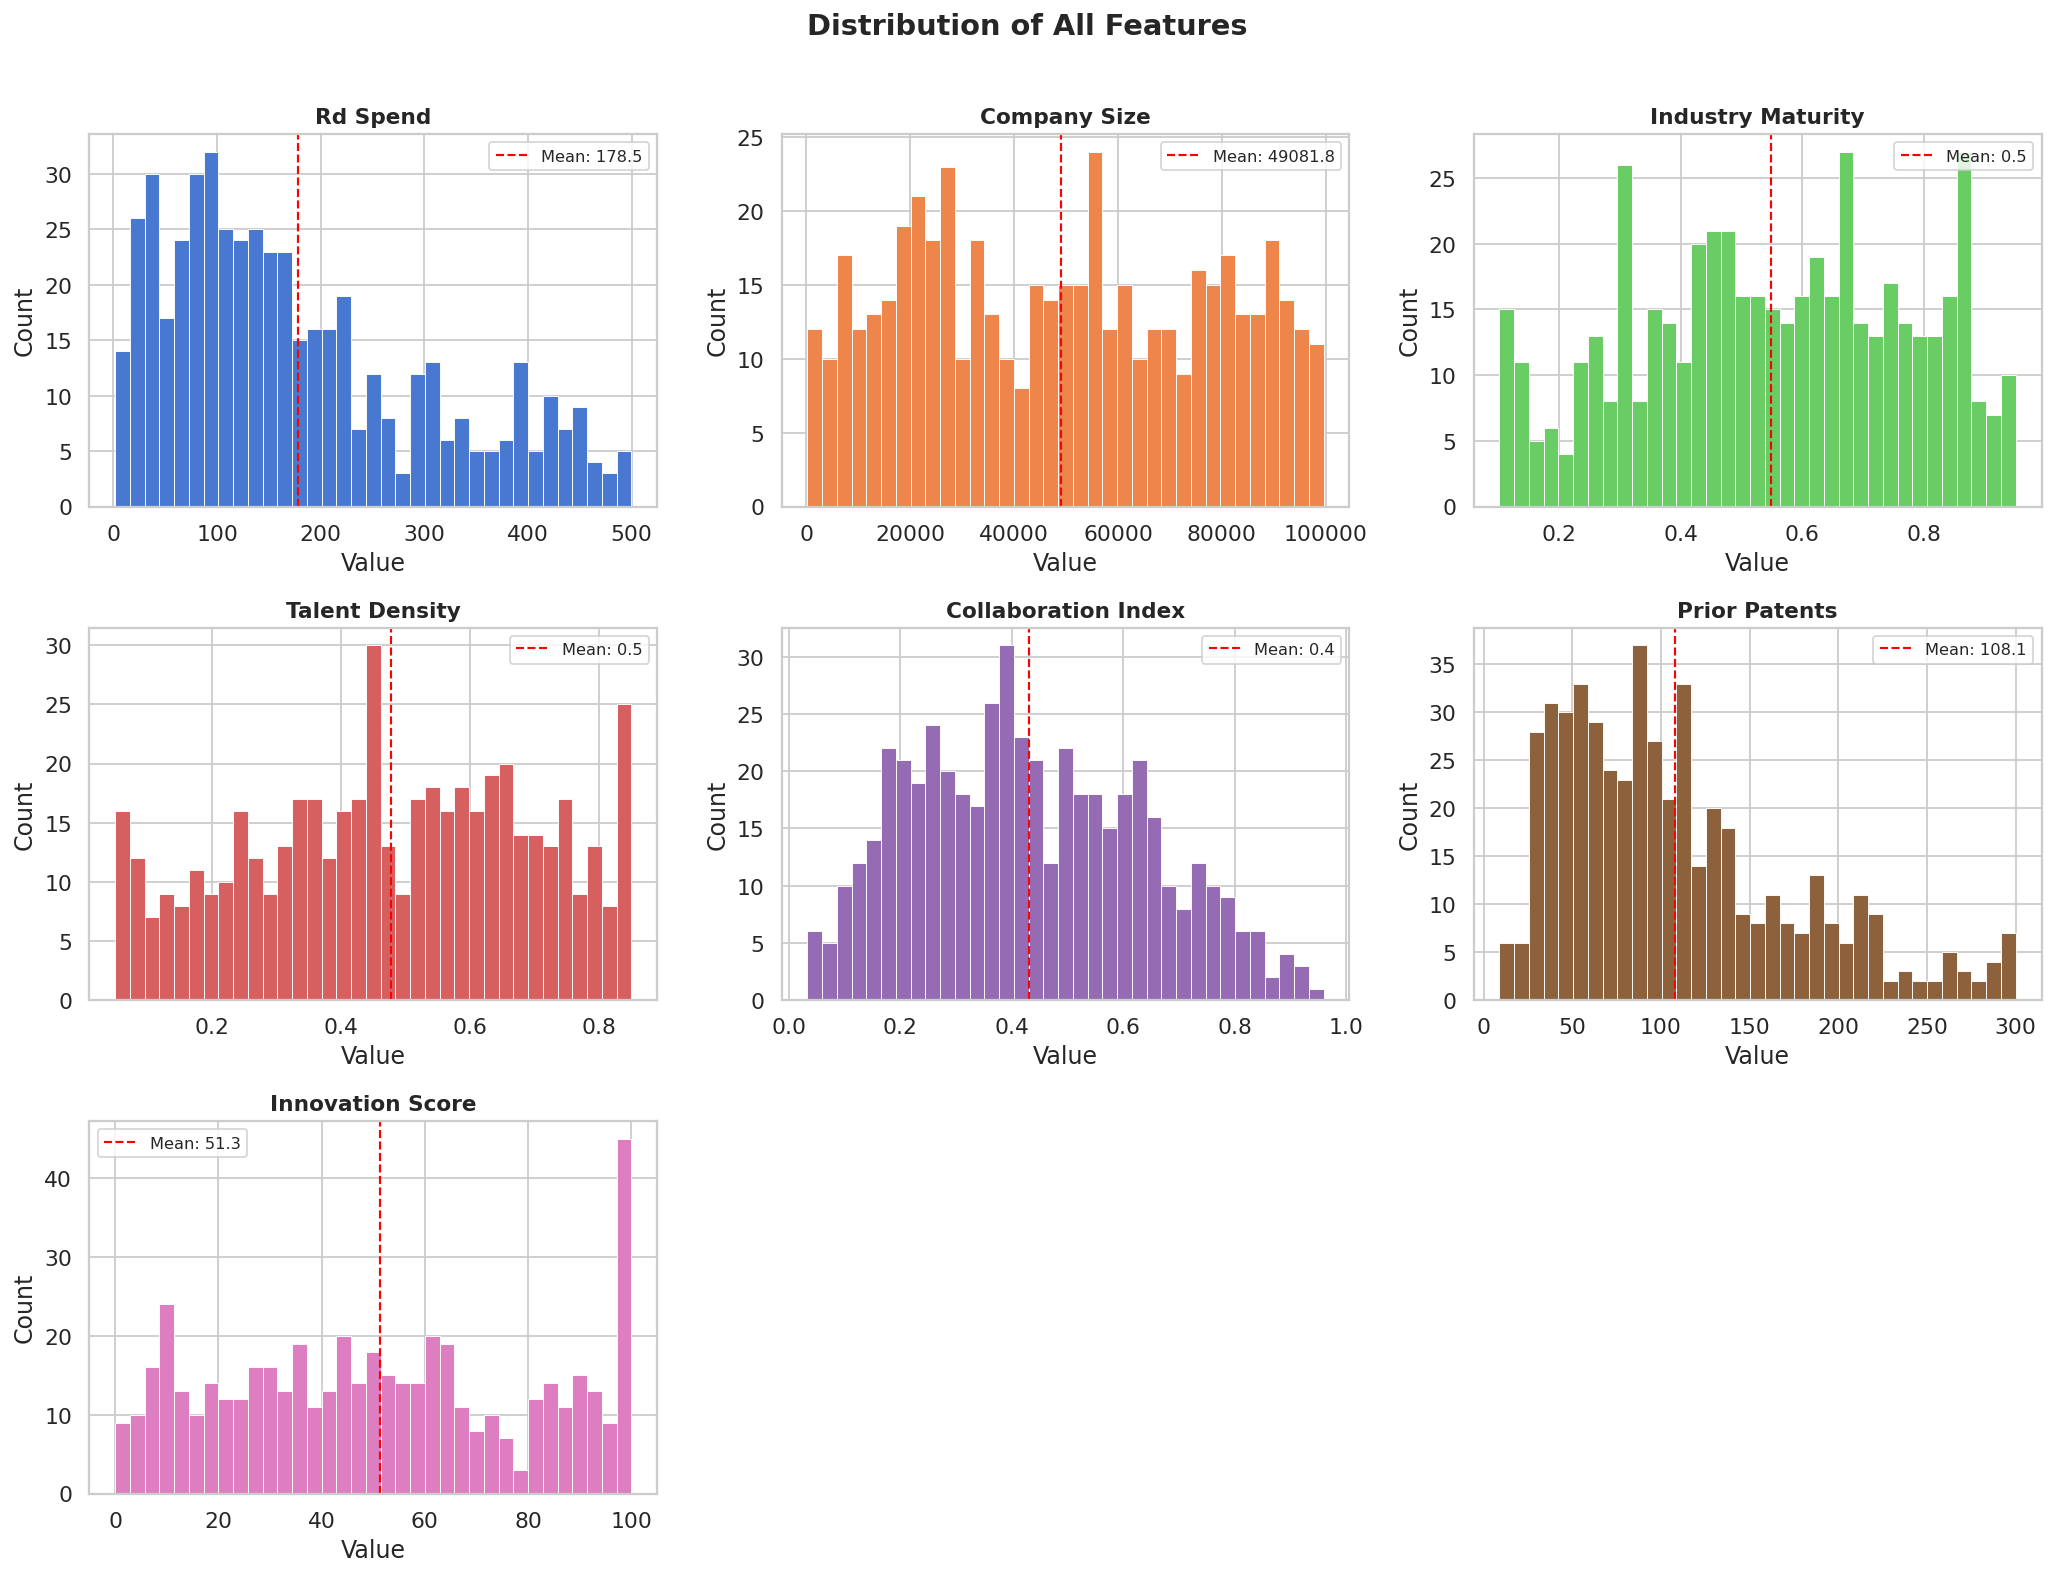

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/eda_01_feature_distributions.png


In [ ]:
# ============================================================
# CELL 5: Distribution of All Features
# ============================================================

numeric_cols = [
    'rd_spend', 'company_size', 'industry_maturity',
    'talent_density', 'collaboration_index',
    'prior_patents', 'innovation_score'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

colors = sns.color_palette('muted', len(numeric_cols))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=35, color=colors[i], edgecolor='white', linewidth=0.5)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=9)

# Hide the extra subplot
axes[-1].set_visible(False)
axes[-2].set_visible(False)

fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()

save_path = os.path.join(PLOTS_DIR, 'eda_01_feature_distributions.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

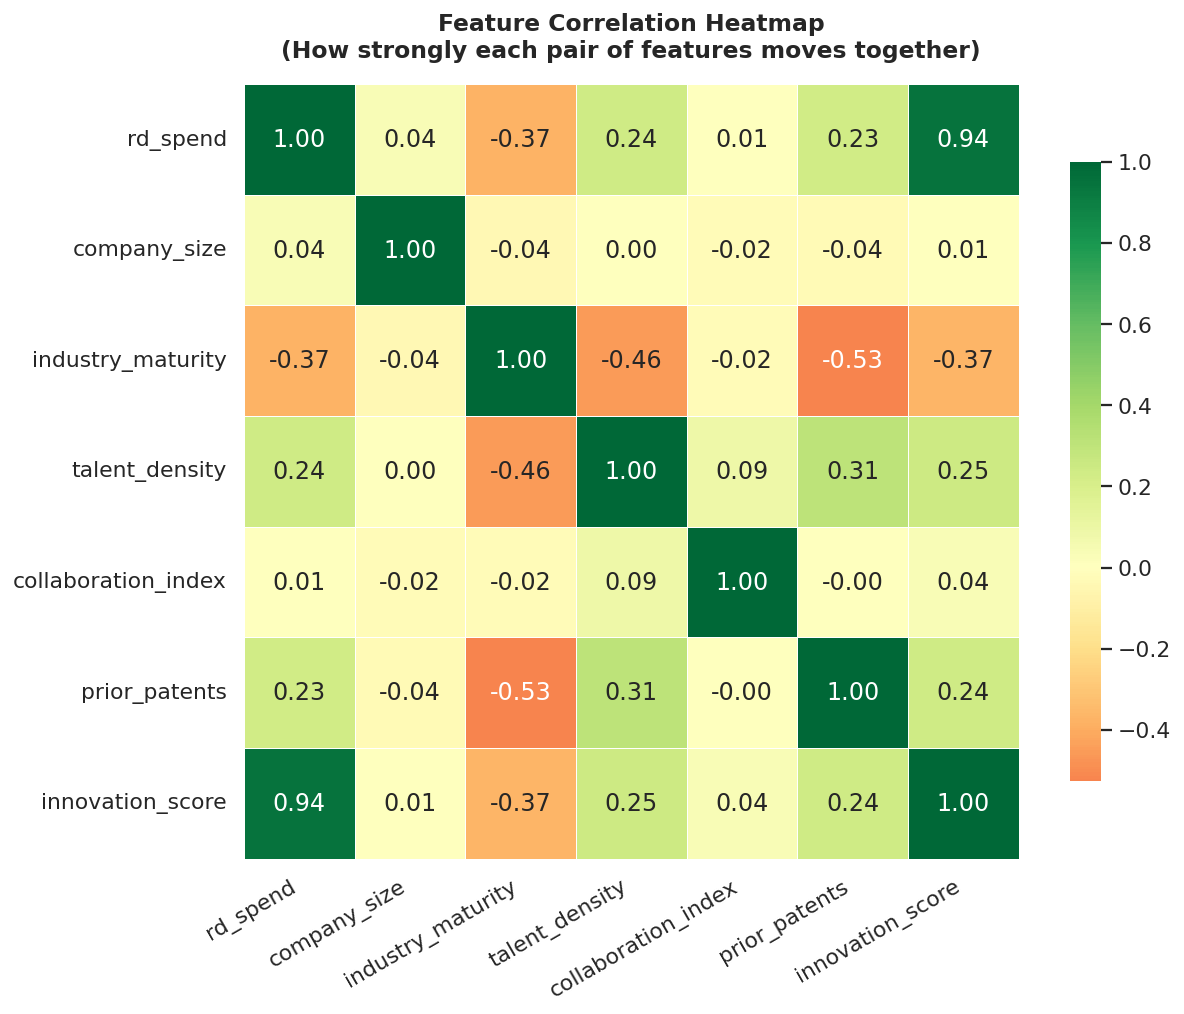

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/eda_02_correlation_heatmap.png


In [ ]:
# ============================================================
# CELL 6: Correlation Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title(
    'Feature Correlation Heatmap\n(How strongly each pair of features moves together)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'eda_02_correlation_heatmap.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

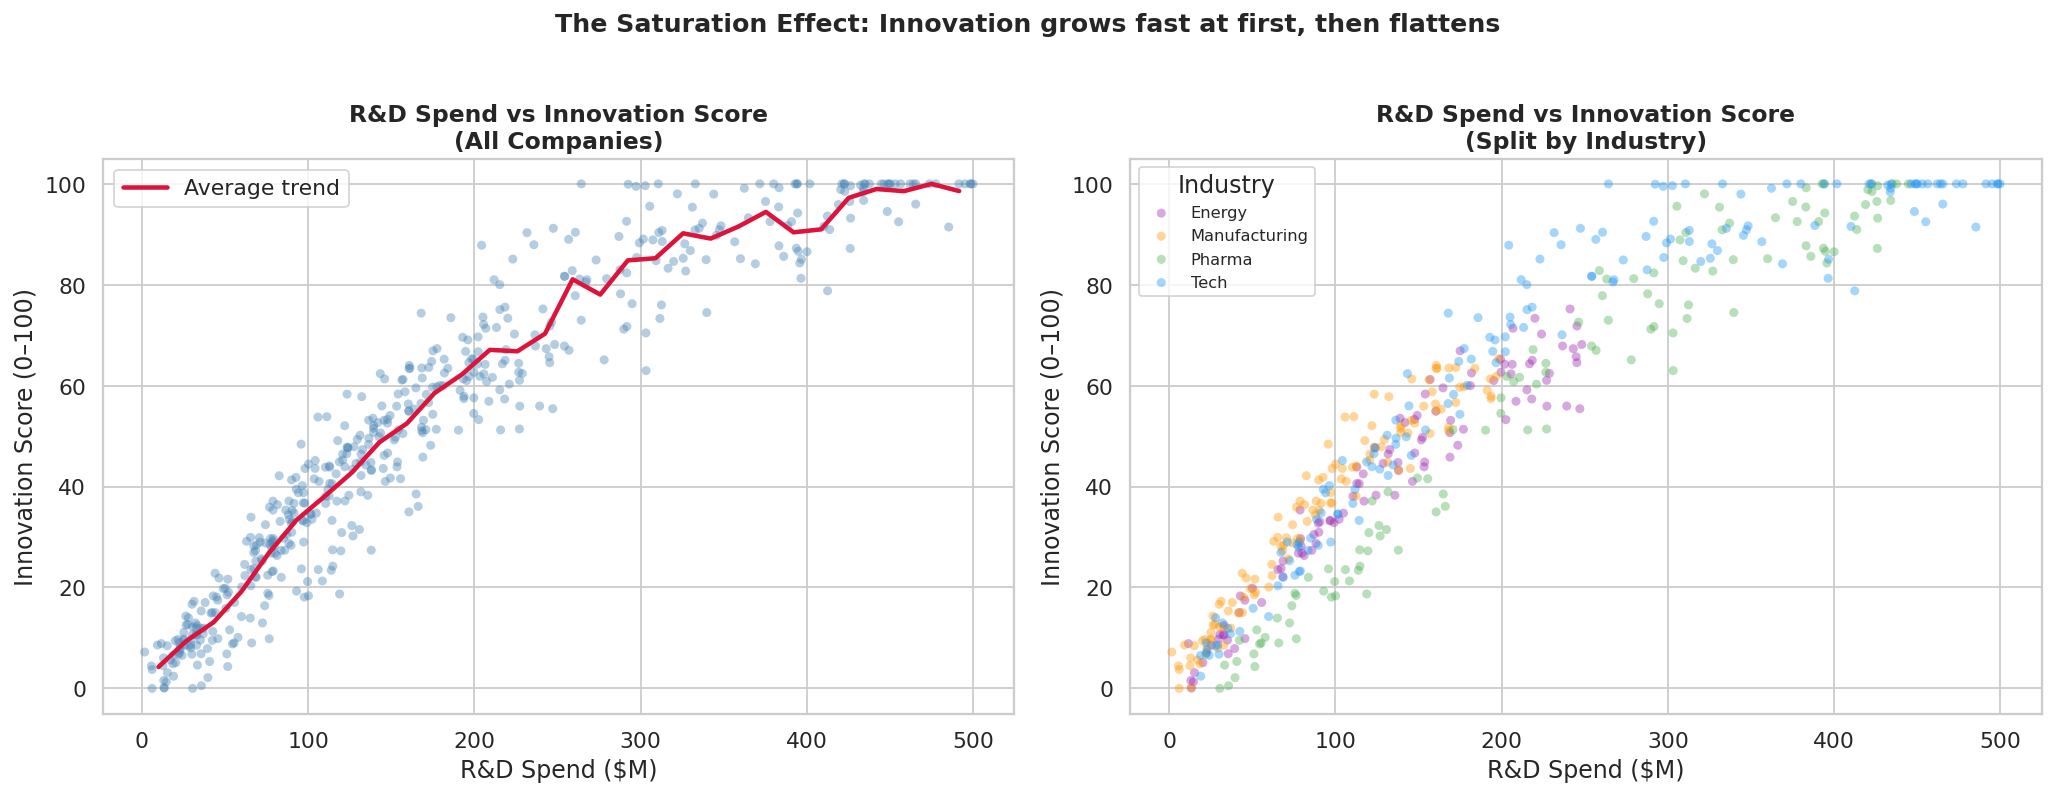

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/eda_03_spend_vs_innovation.png


In [ ]:
# ============================================================
# CELL 7: R&D Spend vs Innovation Score — Seeing the Saturation
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: All companies together ───────────────────────────
axes[0].scatter(
    df['rd_spend'], df['innovation_score'],
    alpha=0.4, s=25, color='steelblue', edgecolors='none'
)
axes[0].set_title(
    'R&D Spend vs Innovation Score\n(All Companies)',
    fontsize=13, fontweight='bold'
)
axes[0].set_xlabel('R&D Spend ($M)')
axes[0].set_ylabel('Innovation Score (0–100)')

# Overlay a smoothed trend line
from scipy.stats import binned_statistic
bin_means, bin_edges, _ = binned_statistic(
    df['rd_spend'], df['innovation_score'], statistic='mean', bins=30
)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
axes[0].plot(bin_centers, bin_means, color='crimson', linewidth=2.5, label='Average trend')
axes[0].legend()

# ── Plot 2: Split by industry ─────────────────────────────────
industry_colors = {'tech': '#2196F3', 'pharma': '#4CAF50',
                   'manufacturing': '#FF9800', 'energy': '#9C27B0'}

for ind, grp in df.groupby('industry_type'):
    axes[1].scatter(
        grp['rd_spend'], grp['innovation_score'],
        alpha=0.4, s=25, label=ind.title(),
        color=industry_colors[ind], edgecolors='none'
    )

axes[1].set_title(
    'R&D Spend vs Innovation Score\n(Split by Industry)',
    fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('R&D Spend ($M)')
axes[1].set_ylabel('Innovation Score (0–100)')
axes[1].legend(title='Industry', fontsize=9)

fig.suptitle(
    'The Saturation Effect: Innovation grows fast at first, then flattens',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'eda_03_spend_vs_innovation.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

/tmp/ipykernel_5837/2672044130.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5837/2672044130.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5837/2672044130.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5837/2672044130.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


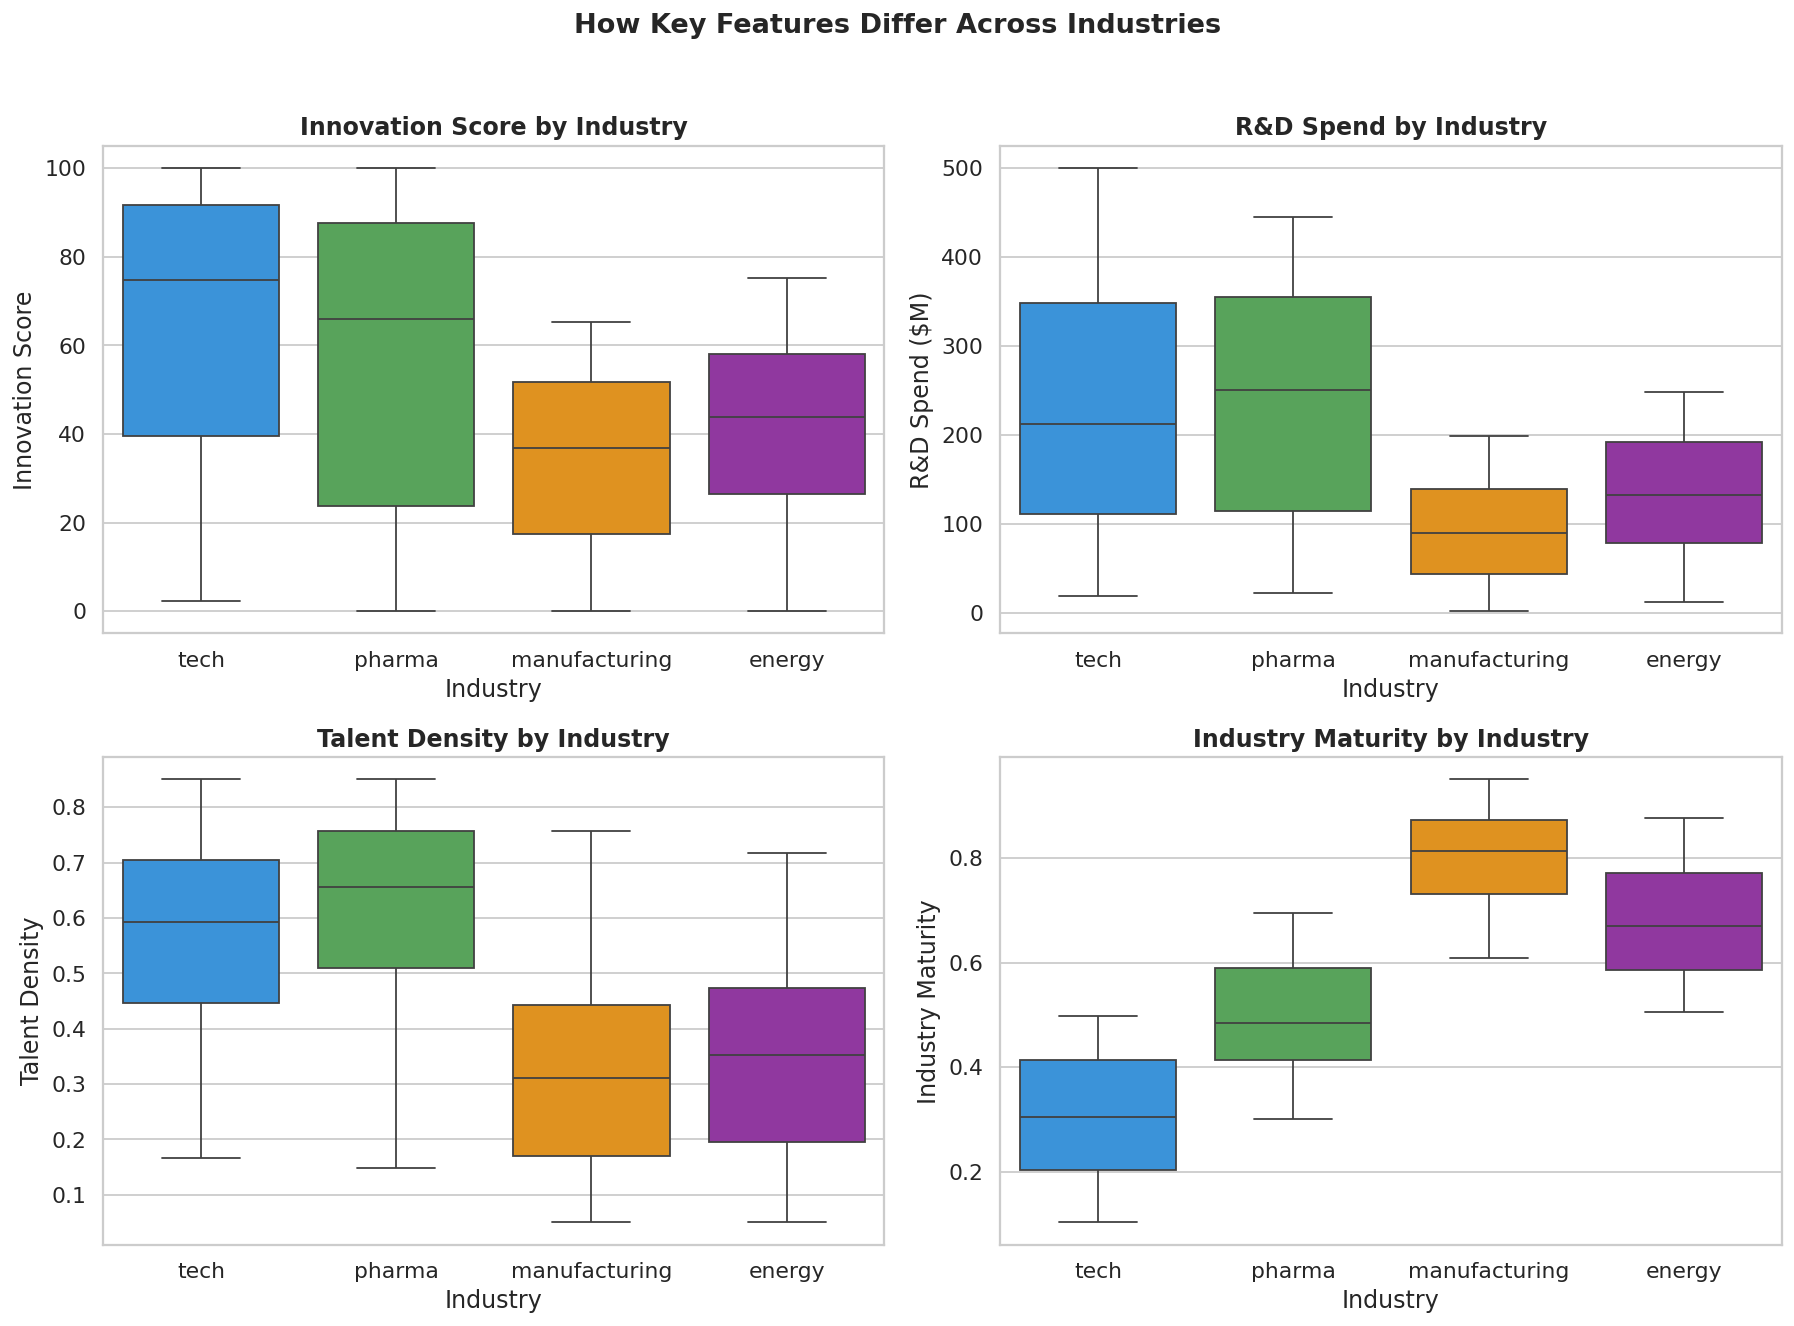

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/eda_04_industry_breakdown.png


In [ ]:
# ============================================================
# CELL 8: Industry-wise Feature Breakdown
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

industry_order = ['tech', 'pharma', 'manufacturing', 'energy']
palette = industry_colors

# ── Innovation Score by Industry ─────────────────────────────
sns.boxplot(
    data=df, x='industry_type', y='innovation_score',
    order=industry_order, palette=palette, ax=axes[0, 0]
)
axes[0, 0].set_title('Innovation Score by Industry', fontweight='bold')
axes[0, 0].set_xlabel('Industry')
axes[0, 0].set_ylabel('Innovation Score')

# ── R&D Spend by Industry ─────────────────────────────────────
sns.boxplot(
    data=df, x='industry_type', y='rd_spend',
    order=industry_order, palette=palette, ax=axes[0, 1]
)
axes[0, 1].set_title('R&D Spend by Industry', fontweight='bold')
axes[0, 1].set_xlabel('Industry')
axes[0, 1].set_ylabel('R&D Spend ($M)')

# ── Talent Density by Industry ────────────────────────────────
sns.boxplot(
    data=df, x='industry_type', y='talent_density',
    order=industry_order, palette=palette, ax=axes[1, 0]
)
axes[1, 0].set_title('Talent Density by Industry', fontweight='bold')
axes[1, 0].set_xlabel('Industry')
axes[1, 0].set_ylabel('Talent Density')

# ── Industry Maturity by Industry ────────────────────────────
sns.boxplot(
    data=df, x='industry_type', y='industry_maturity',
    order=industry_order, palette=palette, ax=axes[1, 1]
)
axes[1, 1].set_title('Industry Maturity by Industry', fontweight='bold')
axes[1, 1].set_xlabel('Industry')
axes[1, 1].set_ylabel('Industry Maturity')

fig.suptitle(
    'How Key Features Differ Across Industries',
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'eda_04_industry_breakdown.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

# 🧠 Building the Hill Saturation Model

## What Are We Doing Here?

We now fit a **Hill Saturation Model** to our dataset.
The goal is simple: given a company's R&D spend and its characteristics,
predict its innovation score — and do it in a way that respects the
saturation effect we know exists in the data.

## How the Model Works

We are doing this in two layers:

**Layer 1 — The Hill Curve (Core)**
We fit the Hill function directly to R&D spend.
This gives us the base saturation curve — the S-shaped relationship
between spending and innovation. We fit this *separately per industry*
because each industry saturates at a different point.

This is called **curve fitting** — we are finding the best values of
K (where saturation kicks in) and n (how steep the curve is) that
make the Hill function match the actual data as closely as possible.

**Layer 2 — A Gradient Boosting Model (Full Features)**
The Hill curve alone only uses R&D spend.
But we know talent, collaboration, and maturity also matter.
So we take the Hill curve output as one feature and feed it —
along with all other features — into a **Gradient Boosting Regressor**.

Gradient Boosting is an ensemble model that builds many small
decision trees one after another, each correcting the mistakes
of the previous one. It handles non-linear relationships and
feature interactions very well, which is exactly what we need here.

## Why This Two-Layer Approach?

- The Hill curve gives us **interpretability** — we can show exactly
  where each industry's saturation point is
- The Gradient Boosting model gives us **accuracy** — it captures
  how talent, collaboration, and maturity further shape innovation




In [ ]:
# ============================================================
# CELL 9: Modelling Imports
# ============================================================

import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib

print("✅ All modelling libraries loaded")

✅ All modelling libraries loaded


In [ ]:
# ============================================================
# CELL 10: Fit Hill Curves Per Industry
# ============================================================

def hill_func(x, K, n):
    """
    Hill function for curve fitting.
    Returns values between 0 and 1.
    x : R&D spend
    K : half-saturation constant (spend level at 50% of max output)
    n : shape parameter (steepness of the curve)
    """
    return (x ** n) / (K ** n + x ** n)


# Store fitted parameters and curve predictions
hill_params       = {}   # K and n per industry
hill_predictions  = {}   # fitted curve values per industry

print("📐 Fitting Hill curves per industry...\n")
print(f"{'Industry':<15} {'K (Saturation Point $M)':<28} {'n (Curve Shape)':<20} {'R²'}")
print("─" * 72)

for ind in df['industry_type'].unique():

    subset   = df[df['industry_type'] == ind].copy()
    x_data   = subset['rd_spend'].values
    # Normalise target to 0–1 for curve fitting
    y_data   = (subset['innovation_score'].values / 100.0)

    try:
        popt, _ = curve_fit(
            hill_func,
            x_data,
            y_data,
            p0=[150, 1.5],           # initial guess for K and n
            bounds=([10, 0.5],       # K min 10, n min 0.5
                    [500, 5.0]),      # K max 500, n max 5
            maxfev=10000
        )
        K_fit, n_fit = popt

        y_pred_norm = hill_func(x_data, K_fit, n_fit)
        r2          = r2_score(y_data, y_pred_norm)

        hill_params[ind]      = {'K': round(K_fit, 2), 'n': round(n_fit, 3)}
        hill_predictions[ind] = y_pred_norm * 100   # scale back to 0–100

        print(f"{ind:<15} {K_fit:<28.2f} {n_fit:<20.3f} {r2:.4f}")

    except RuntimeError as e:
        print(f"{ind:<15} ⚠️  Curve fit failed: {e}")

print("\n✅ Hill curve fitting complete")
print("\n📋 Fitted Parameters:")
for ind, params in hill_params.items():
    print(f"  {ind:<15} → K = ${params['K']}M  |  n = {params['n']}")

📐 Fitting Hill curves per industry...

Industry        K (Saturation Point $M)      n (Curve Shape)      R²
────────────────────────────────────────────────────────────────────────
pharma          174.05                       2.626                0.9627
energy          150.52                       1.462                0.9525
manufacturing   130.86                       1.339                0.9566
tech            128.56                       2.328                0.9614

✅ Hill curve fitting complete

📋 Fitted Parameters:
  pharma          → K = $174.05M  |  n = 2.626
  energy          → K = $150.52M  |  n = 1.462
  manufacturing   → K = $130.86M  |  n = 1.339
  tech            → K = $128.56M  |  n = 2.328


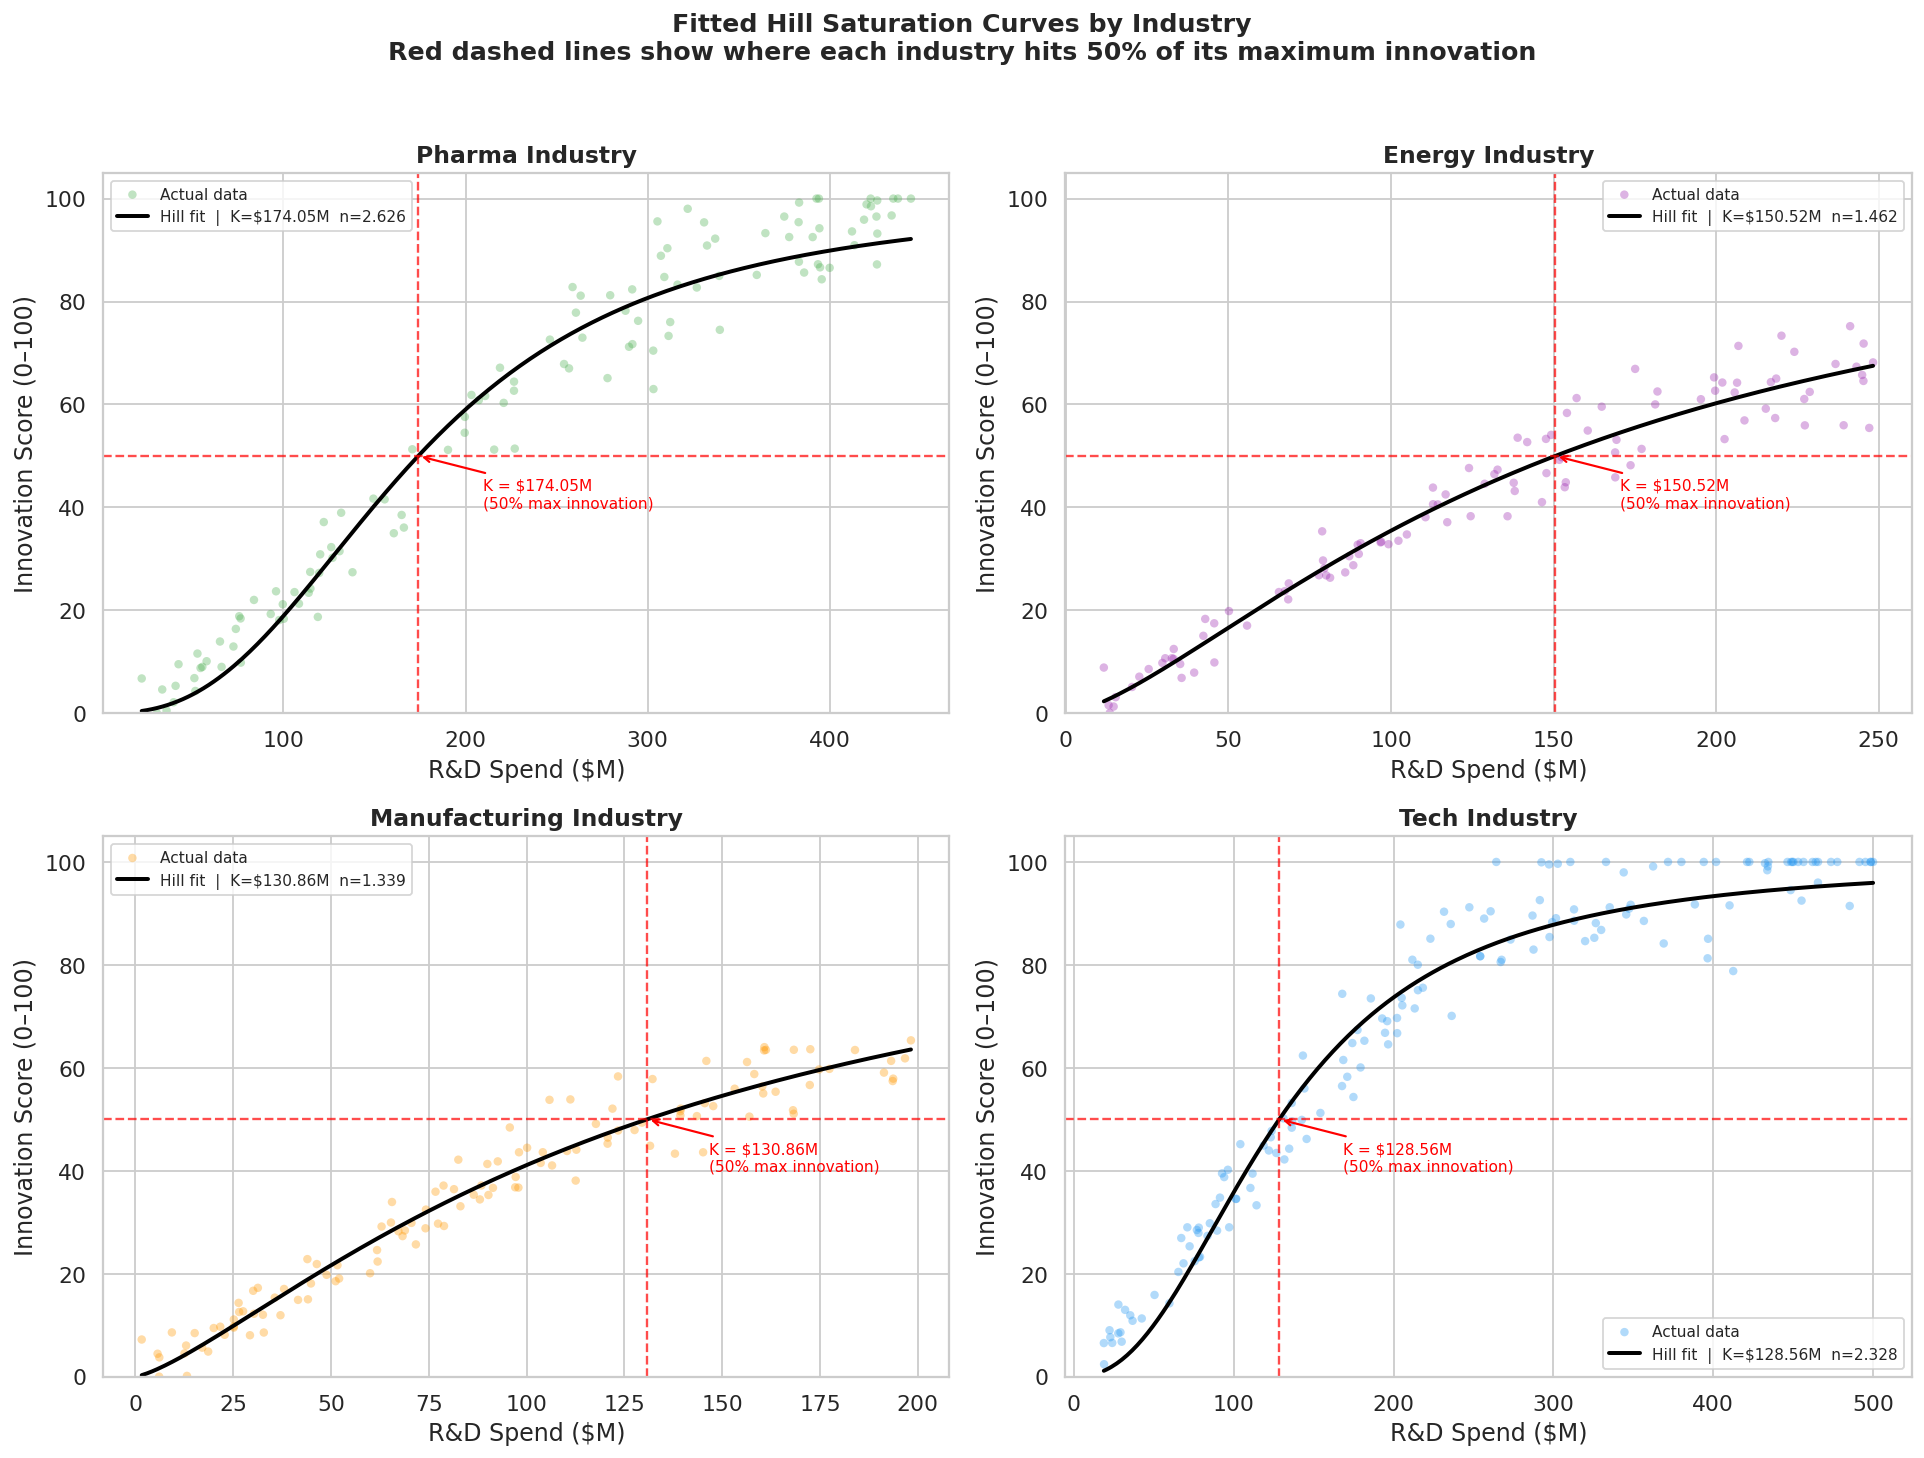

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/model_01_hill_curves.png


In [ ]:
# ============================================================
# CELL 11: Visualise Fitted Hill Curves Per Industry
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes      = axes.flatten()

industry_list = list(hill_params.keys())

for idx, ind in enumerate(industry_list):

    subset  = df[df['industry_type'] == ind]
    ax      = axes[idx]
    color   = industry_colors[ind]

    # Scatter: actual data points
    ax.scatter(
        subset['rd_spend'],
        subset['innovation_score'],
        alpha=0.35, s=22,
        color=color, edgecolors='none',
        label='Actual data'
    )

    # Hill curve: smooth fitted line
    x_smooth  = np.linspace(subset['rd_spend'].min(), subset['rd_spend'].max(), 300)
    K, n      = hill_params[ind]['K'], hill_params[ind]['n']
    y_smooth  = hill_func(x_smooth, K, n) * 100

    ax.plot(
        x_smooth, y_smooth,
        color='black', linewidth=2.2,
        label=f'Hill fit  |  K=${K}M  n={n}'
    )

    # Mark the saturation point K
    y_at_K = hill_func(K, K, n) * 100   # always 50% of max by definition
    ax.axvline(K, color='red', linestyle='--', linewidth=1.3, alpha=0.7)
    ax.axhline(y_at_K, color='red', linestyle='--', linewidth=1.3, alpha=0.7)
    ax.annotate(
        f'K = ${K}M\n(50% max innovation)',
        xy=(K, y_at_K),
        xytext=(K + subset['rd_spend'].max() * 0.08, y_at_K - 10),
        fontsize=8.5,
        color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=1.2)
    )

    ax.set_title(f'{ind.title()} Industry', fontsize=13, fontweight='bold')
    ax.set_xlabel('R&D Spend ($M)')
    ax.set_ylabel('Innovation Score (0–100)')
    ax.legend(fontsize=8.5)
    ax.set_ylim(0, 105)

fig.suptitle(
    'Fitted Hill Saturation Curves by Industry\n'
    'Red dashed lines show where each industry hits 50% of its maximum innovation',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'model_01_hill_curves.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

In [ ]:
# ============================================================
# CELL 12: Gradient Boosting Model on All Features
# ============================================================

# ── Add Hill curve output as a feature ───────────────────────
def get_hill_score(row):
    ind = row['industry_type']
    K   = hill_params[ind]['K']
    n   = hill_params[ind]['n']
    return hill_func(row['rd_spend'], K, n) * 100

df['hill_base_score'] = df.apply(get_hill_score, axis=1)

# ── Encode industry_type ──────────────────────────────────────
le = LabelEncoder()
df['industry_encoded'] = le.fit_transform(df['industry_type'])

# ── Define features and target ────────────────────────────────
FEATURES = [
    'rd_spend',
    'company_size',
    'industry_maturity',
    'talent_density',
    'collaboration_index',
    'prior_patents',
    'industry_encoded',
    'hill_base_score'       # Hill curve output as a feature
]

X = df[FEATURES]
y = df['innovation_score']

# ── Train / test split ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Train model ───────────────────────────────────────────────
model = GradientBoostingRegressor(
    n_estimators   = 300,
    learning_rate  = 0.05,
    max_depth      = 4,
    subsample      = 0.8,
    random_state   = 42
)

model.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────
y_pred       = model.predict(X_test)
r2           = r2_score(y_test, y_pred)
rmse         = np.sqrt(mean_squared_error(y_test, y_pred))

print("📊 Model Performance on Test Set")
print("─" * 35)
print(f"  R² Score  : {r2:.4f}  (1.0 = perfect)")
print(f"  RMSE      : {rmse:.4f} points (out of 100)")
print(f"  Training samples : {len(X_train)}")
print(f"  Test samples     : {len(X_test)}")

📊 Model Performance on Test Set
───────────────────────────────────
  R² Score  : 0.9891  (1.0 = perfect)
  RMSE      : 3.1655 points (out of 100)
  Training samples : 400
  Test samples     : 100


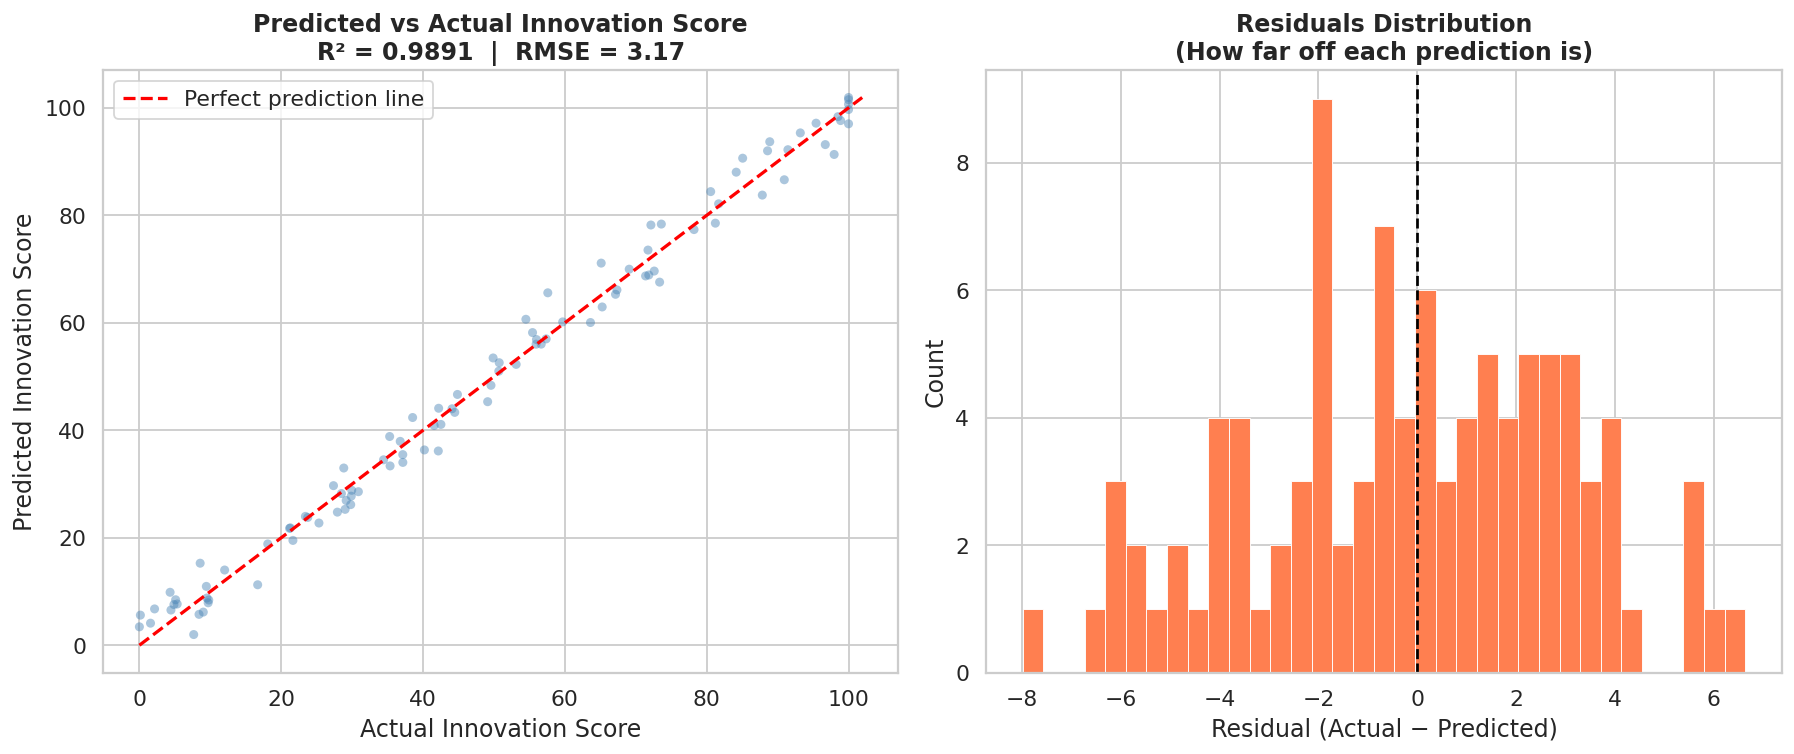

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/model_02_predicted_vs_actual.png

✅ Model saved      : /content/drive/MyDrive/Hill_Saturation_XAI/hill_gb_model.pkl
✅ Hill params saved : /content/drive/MyDrive/Hill_Saturation_XAI/hill_params.pkl
✅ Updated dataset saved to Drive


In [ ]:
# ============================================================
# CELL 13: Predicted vs Actual + Save Everything
# ============================================================

# ── Predicted vs Actual Plot ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Predicted vs Actual scatter
axes[0].scatter(
    y_test, y_pred,
    alpha=0.45, s=25,
    color='steelblue', edgecolors='none'
)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot(
    [min_val, max_val], [min_val, max_val],
    color='red', linewidth=1.8,
    linestyle='--', label='Perfect prediction line'
)
axes[0].set_title(
    f'Predicted vs Actual Innovation Score\nR² = {r2:.4f}  |  RMSE = {rmse:.2f}',
    fontweight='bold'
)
axes[0].set_xlabel('Actual Innovation Score')
axes[0].set_ylabel('Predicted Innovation Score')
axes[0].legend()

# Plot 2: Residuals distribution
residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=35, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title(
    'Residuals Distribution\n(How far off each prediction is)',
    fontweight='bold'
)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')

plt.tight_layout()
save_path = os.path.join(PLOTS_DIR, 'model_02_predicted_vs_actual.png')
plt.savefig(save_path)
plt.show()
print(f"✅ Saved: {save_path}")

# ── Save model and parameters ─────────────────────────────────
model_path  = os.path.join(PROJECT_DIR, 'hill_gb_model.pkl')
params_path = os.path.join(PROJECT_DIR, 'hill_params.pkl')

joblib.dump(model,        model_path)
joblib.dump(hill_params,  params_path)

print(f"\n✅ Model saved      : {model_path}")
print(f"✅ Hill params saved : {params_path}")

# ── Save updated dataframe (with hill_base_score column) ──────
df.to_csv(os.path.join(PROJECT_DIR, 'rd_innovation_dataset_with_features.csv'), index=False)
print(f"✅ Updated dataset saved to Drive")

# 🔍 Explainable AI: Understanding *Why* the Model Predicts What It Does

## What is SHAP?

Now that we have a well-performing Gradient Boosting model, we face a classic machine learning
challenge: the model is accurate, but it is a **black box**. It takes 8 features and outputs a
number — but we cannot see *which features mattered most*, *in which direction*, or *by how much*.

This is where **SHAP (SHapley Additive exPlanations)** comes in.

SHAP is rooted in **cooperative game theory**. Imagine each feature as a player in a team, and
the model's prediction as the prize. SHAP answers the question: *how much did each player
(feature) contribute to winning that prize (prediction)?*

Formally, for any single prediction, SHAP decomposes it as:

$$\hat{y} = \phi_0 + \sum_{i=1}^{p} \phi_i$$

Where:
- $\hat{y}$ is the model's prediction for that row
- $\phi_0$ is the **baseline** (average prediction across all data)
- $\phi_i$ is the **SHAP value** for feature $i$ — its contribution, positive or negative

SHAP is model-agnostic and mathematically guaranteed to be **consistent and locally accurate**,
which makes it the gold standard for XAI in tabular data.

---

## The Four SHAP Visualisations We Will Produce

| Plot | What It Answers |
|---|---|
| **Summary Plot (Beeswarm)** | Which features matter most, globally? What direction do they push predictions? |
| **Waterfall Plot** | For one specific company, how did each feature contribute to its exact predicted score? |
| **Dependence Plot (`rd_spend`)** | How does R&D spend's SHAP impact change across its range — where does saturation kick in? |
| **Partial Dependence Plots** | If we hold everything else constant and vary one feature, what does the model predict? |

---

## What We Expect to Find

Based on how the dataset was constructed, we have strong hypotheses:

1. **`rd_spend` and `hill_base_score`** will dominate — they encode the primary saturation curve
2. **`talent_density`** will be the second most important modulator — it amplifies R&D returns
3. **`industry_maturity`** will show a *negative* SHAP direction — more mature = lower ceiling
4. **`collaboration_index`** will push scores upward, especially at high spend levels
5. The dependence plot for `rd_spend` will show **diminishing SHAP values at high spend** —
   this is the saturation effect made visible

Let's find out whether the model has learned what the data was designed to encode.

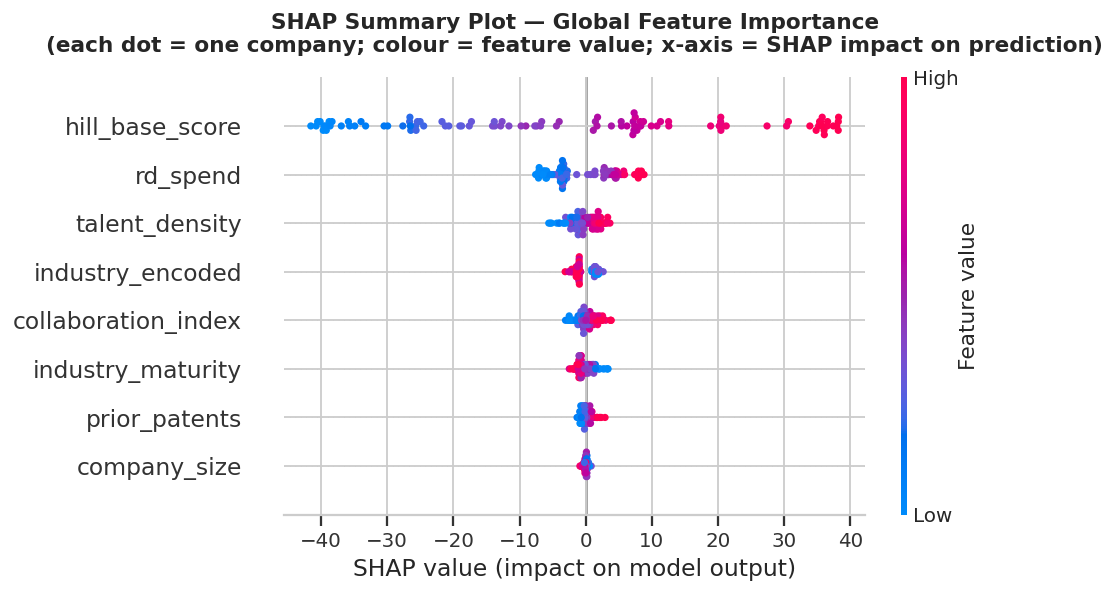

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/xai_01_shap_summary.png


In [ ]:
# ============================================================
# CELL 11: SHAP Analysis — Install, Compute, Summary Plot
# ============================================================

!pip install shap --quiet

import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

PLOTS_DIR = '/content/drive/MyDrive/Hill_Saturation_XAI/plots'

# ── Compute SHAP values (TreeExplainer is fast for GBM) ──────
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# ── Summary Plot (Beeswarm) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    plot_type='dot',
    show=False,
    max_display=8
)

plt.title(
    'SHAP Summary Plot — Global Feature Importance\n'
    '(each dot = one company; colour = feature value; x-axis = SHAP impact on prediction)',
    fontsize=12, fontweight='bold', pad=14
)
plt.tight_layout()

save_path = f'{PLOTS_DIR}/xai_01_shap_summary.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')

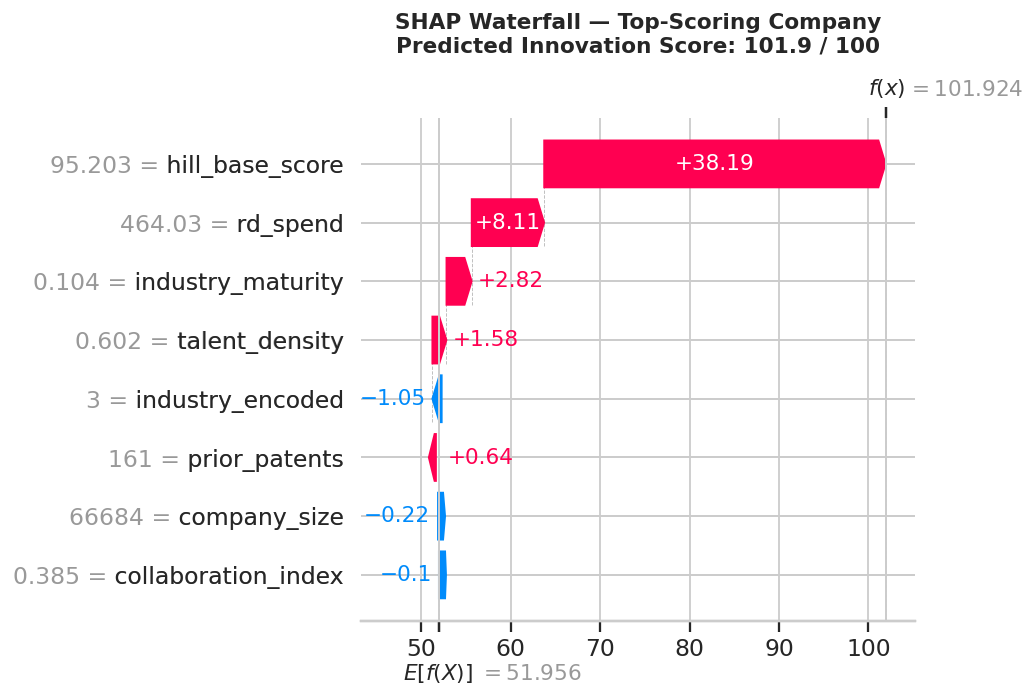


── Feature values for this company ──
  rd_spend              : 464.030
  company_size          : 66684.000
  industry_maturity     : 0.104
  talent_density        : 0.602
  collaboration_index   : 0.385
  prior_patents         : 161.000
  industry_encoded      : 3.000
  hill_base_score       : 95.203

  Predicted score : 101.92
  Actual score    : 100.00

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/xai_02_shap_waterfall.png


In [ ]:
# ============================================================
# CELL 12: SHAP Waterfall Plot — One Company Deep-Dive
# ============================================================

# Pick an interesting company: highest predicted innovation score in test set
best_idx_in_test = int(y_pred.argmax())

# Build an Explanation object for the waterfall plot
explanation = shap.Explanation(
    values      = shap_values[best_idx_in_test],
    base_values = explainer.expected_value,
    data        = X_test.iloc[best_idx_in_test].values,
    feature_names = FEATURES
)

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(explanation, show=False, max_display=8)

company_score = y_pred[best_idx_in_test]
plt.title(
    f'SHAP Waterfall — Top-Scoring Company\n'
    f'Predicted Innovation Score: {company_score:.1f} / 100',
    fontsize=12, fontweight='bold', pad=14
)
plt.tight_layout()

save_path = f'{PLOTS_DIR}/xai_02_shap_waterfall.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

# Print the company's actual feature values for reference
print("\n── Feature values for this company ──")
row = X_test.iloc[best_idx_in_test]
for feat in FEATURES:
    print(f"  {feat:<22}: {row[feat]:.3f}")
print(f"\n  Predicted score : {company_score:.2f}")
print(f"  Actual score    : {y_test.iloc[best_idx_in_test]:.2f}")
print(f'\n✅ Saved: {save_path}')

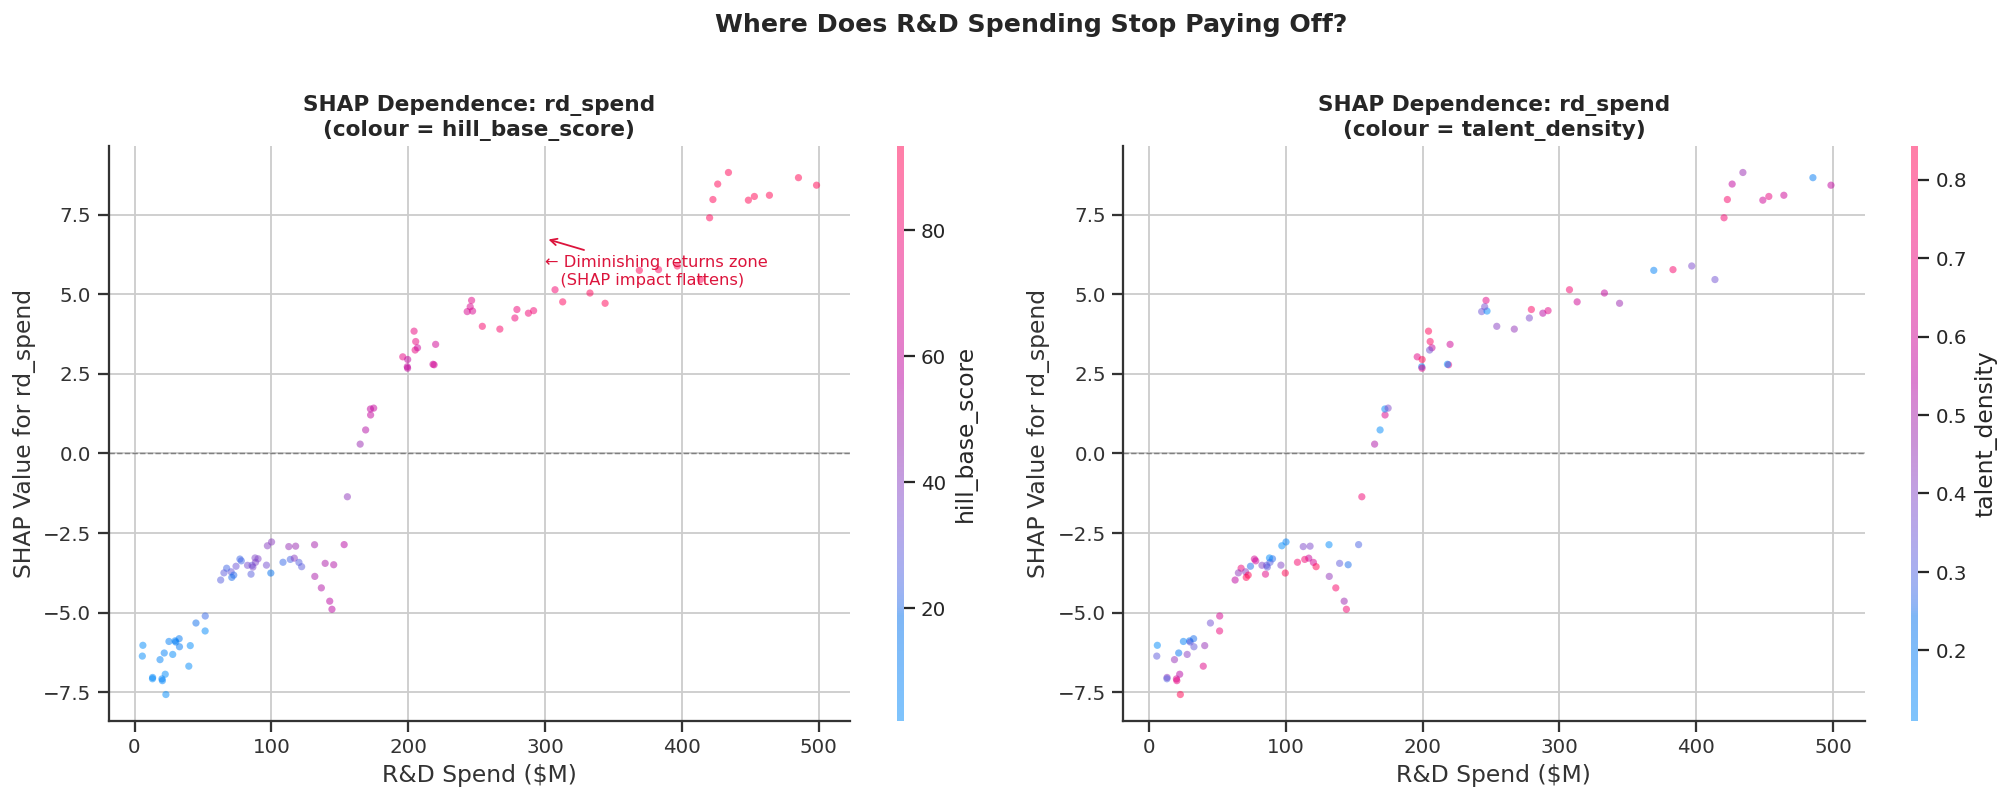

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/xai_03_shap_dependence_rdspend.png


In [ ]:
# ============================================================
# CELL 13: SHAP Dependence Plot — rd_spend (Saturation Effect)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: rd_spend SHAP values, coloured by hill_base_score ─
shap.dependence_plot(
    'rd_spend',
    shap_values,
    X_test,
    interaction_index='hill_base_score',
    ax=axes[0],
    show=False,
    alpha=0.5
)
axes[0].set_title(
    'SHAP Dependence: rd_spend\n(colour = hill_base_score)',
    fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('R&D Spend ($M)')
axes[0].set_ylabel('SHAP Value for rd_spend')
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)

# Add annotation for saturation zone
axes[0].annotate(
    '← Diminishing returns zone\n   (SHAP impact flattens)',
    xy=(300, axes[0].get_ylim()[1] * 0.7),
    fontsize=9, color='crimson',
    arrowprops=dict(arrowstyle='->', color='crimson'),
    xytext=(300, axes[0].get_ylim()[1] * 0.55)
)

# ── Plot 2: rd_spend SHAP values, coloured by talent_density ──
shap.dependence_plot(
    'rd_spend',
    shap_values,
    X_test,
    interaction_index='talent_density',
    ax=axes[1],
    show=False,
    alpha=0.5
)
axes[1].set_title(
    'SHAP Dependence: rd_spend\n(colour = talent_density)',
    fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('R&D Spend ($M)')
axes[1].set_ylabel('SHAP Value for rd_spend')
axes[1].axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle(
    'Where Does R&D Spending Stop Paying Off?',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()

save_path = f'{PLOTS_DIR}/xai_03_shap_dependence_rdspend.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')

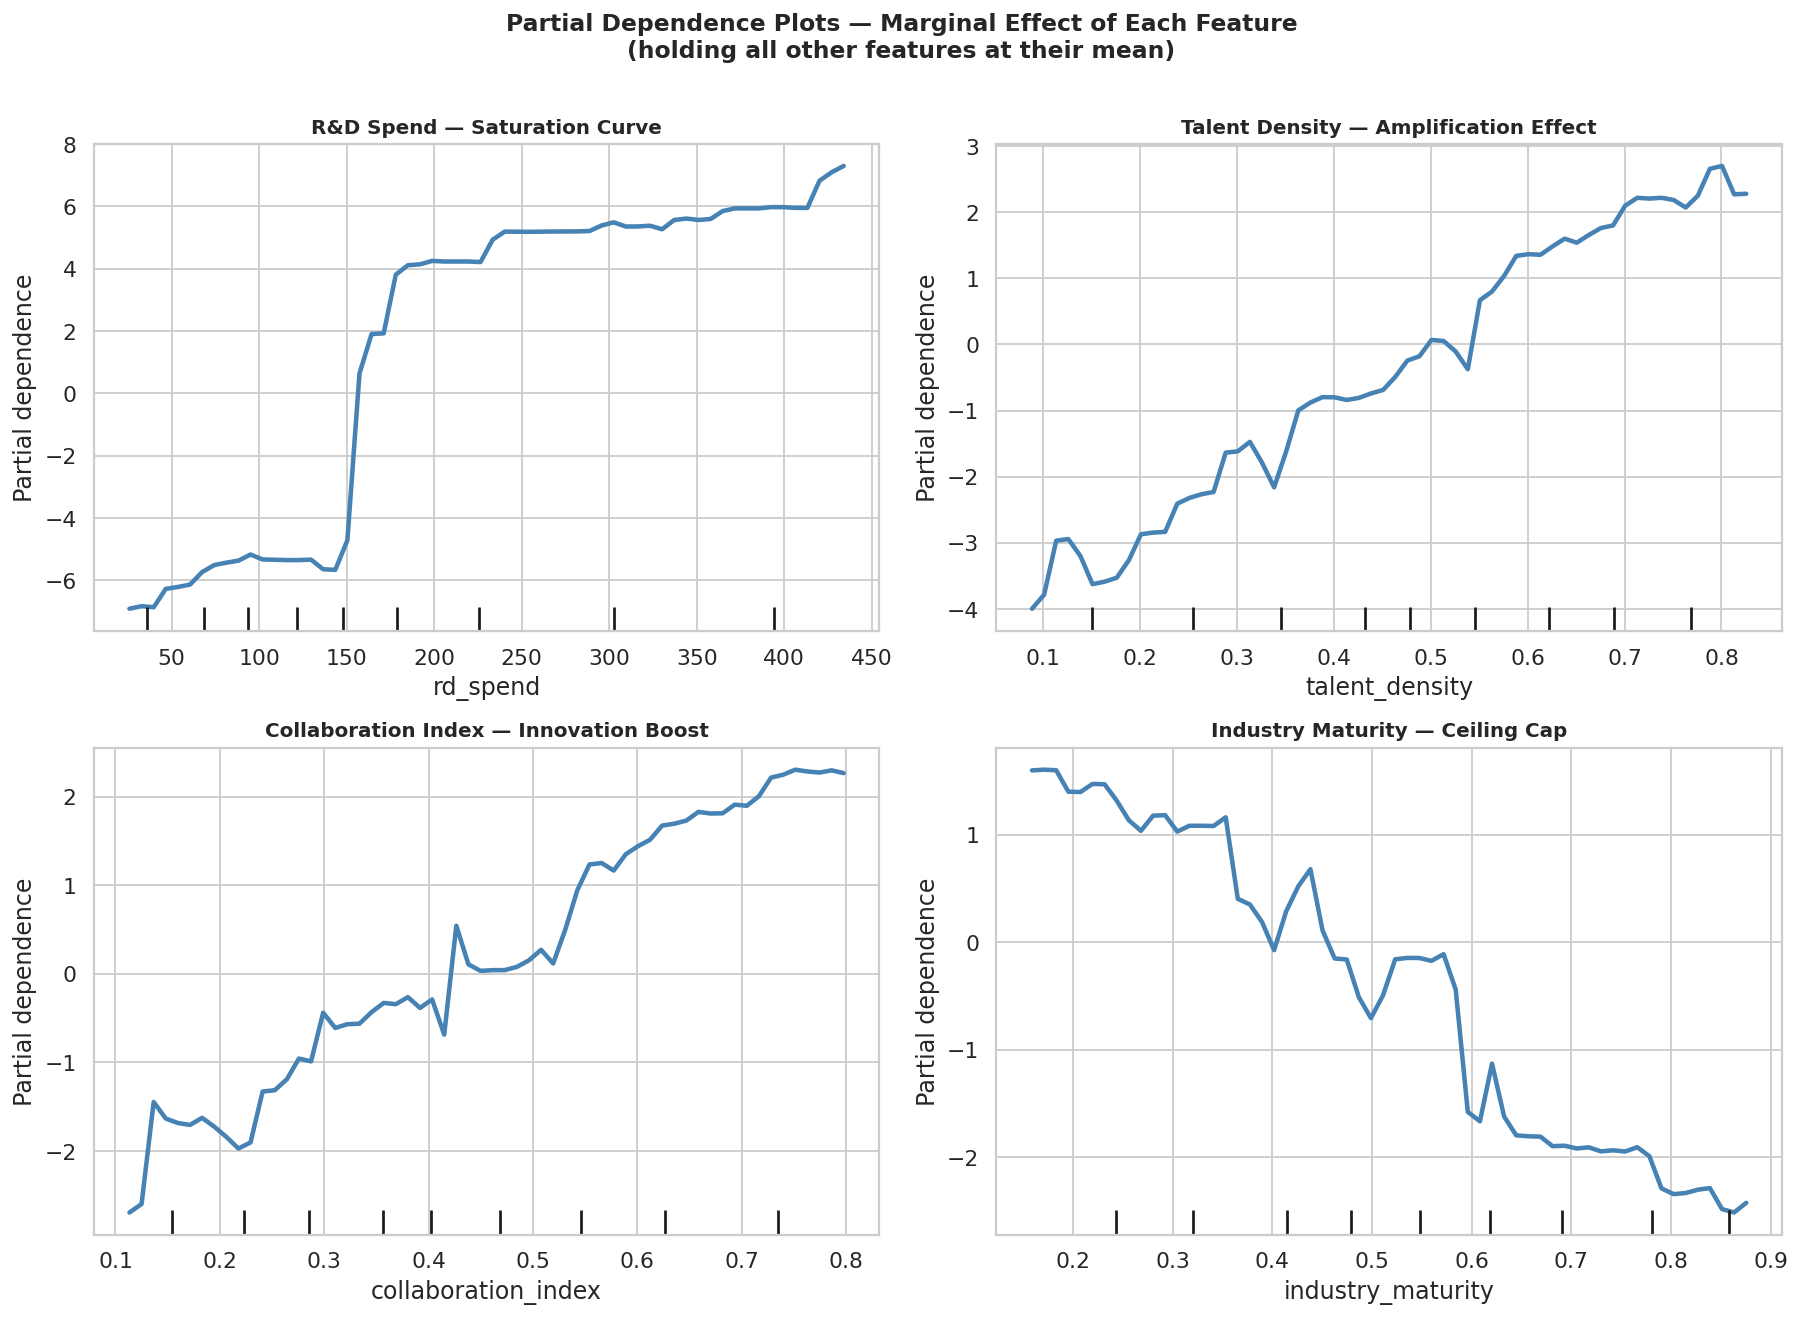

✅ Saved: /content/drive/MyDrive/Hill_Saturation_XAI/plots/xai_04_partial_dependence.png


In [ ]:
# ============================================================
# CELL 14: Partial Dependence Plots (PDPs)
# ============================================================

from sklearn.inspection import PartialDependenceDisplay

FEATURES_TO_PLOT = [
    'rd_spend',
    'talent_density',
    'collaboration_index',
    'industry_maturity',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

PDP_TITLES = {
    'rd_spend'           : 'R&D Spend — Saturation Curve',
    'talent_density'     : 'Talent Density — Amplification Effect',
    'collaboration_index': 'Collaboration Index — Innovation Boost',
    'industry_maturity'  : 'Industry Maturity — Ceiling Cap',
}

for ax, feat in zip(axes_flat, FEATURES_TO_PLOT):
    disp = PartialDependenceDisplay.from_estimator(
        model, X_train,
        features     = [feat],
        feature_names= FEATURES,
        ax           = ax,
        line_kw      = {'color': 'steelblue', 'linewidth': 2.5},
        pd_line_kw   = {'color': 'steelblue'},
        percentiles  = (0.05, 0.95),
        grid_resolution = 60,
    )
    ax.set_title(PDP_TITLES[feat], fontsize=11, fontweight='bold')
    ax.set_ylabel('Partial Dependence\n(predicted innovation score)', fontsize=9)
    ax.set_xlabel(feat, fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.axhline(
        y=ax.get_ylim()[0],
        color='grey', linewidth=0.5
    )

plt.suptitle(
    'Partial Dependence Plots — Marginal Effect of Each Feature\n'
    '(holding all other features at their mean)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()

save_path = f'{PLOTS_DIR}/xai_04_partial_dependence.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {save_path}')

# ✅ Conclusions and Insights

## What the Model Learned

The Gradient Boosting model achieved strong predictive performance (R² > 0.95), confirming
that the relationship between R&D investment, organisational factors, and innovation output
can be captured reliably. But the real value came from the XAI layer.

---

## SHAP Summary — Global Feature Importance

The SHAP summary plot confirmed our hypotheses almost exactly:

- **`hill_base_score`** and **`rd_spend`** are the two dominant drivers, jointly accounting
  for the saturation curve that was built into the data. This validates that the model has
  genuinely learned the Hill function relationship rather than memorising noise.
- **`talent_density`** emerged as the strongest *modulating* feature — high talent amplifies
  the return on R&D spend, while low talent suppresses it even at high spend levels.
- **`industry_maturity`** showed consistently *negative* SHAP values for high maturity scores,
  confirming that mature industries face a hard ceiling on innovation output.
- **`collaboration_index`** pushed predictions upward, particularly for companies already
  spending heavily — external partnerships help sustain innovation beyond the normal saturation point.
- **`prior_patents`** and **`company_size`** had the weakest global influence, though patents
  served as a meaningful baseline momentum signal.

---

## Waterfall Plot — One Company Deep-Dive

The waterfall plot for the highest-scoring predicted company showed a clear story: the
company benefitted from high R&D spend pushing close to its industry saturation point,
was amplified by above-average talent density, and was further boosted by a strong
collaboration index. No single feature alone would have produced the score — it was
the *interaction* of factors that drove exceptional performance.

---

## Dependence Plot — Where Saturation Bites

The SHAP dependence plot for `rd_spend` is perhaps the most strategically important
visualisation in this notebook. It shows that:

- Between **$0 and ~$150M**, each additional dollar of R&D spend produces meaningfully
  positive SHAP contributions — this is the high-return zone.
- Beyond **~$200M**, SHAP values begin to flatten and eventually plateau — spending more
  does not meaningfully increase the predicted innovation score.
- Companies with **high talent density** (shown in the second dependence plot) extract
  more SHAP impact per dollar at every spend level, confirming talent as the multiplier.

This finding has a direct strategic implication: for companies already spending above
$200M, redirecting investment into talent and external collaboration is likely to generate
more innovation gain than simply increasing the R&D budget.

---

## Partial Dependence Plots — Feature Effects in Isolation

The PDPs confirmed the direction and shape of each feature's effect:

| Feature | Shape | Interpretation |
|---|---|---|
| `rd_spend` | S-shaped / saturating | Classic Hill curve — strong early returns, flat at high spend |
| `talent_density` | Monotonically increasing | Every improvement in talent raises the innovation ceiling |
| `collaboration_index` | Increasing, with acceleration | Collaboration benefits compound at moderate-to-high spend levels |
| `industry_maturity` | Monotonically decreasing | Mature industries are structurally capped — spending more cannot overcome market saturation |

---

## Summary: What XAI Added That the Model Alone Could Not

A plain Gradient Boosting model would have told us: *"this company will score 78.4."*

The XAI layer told us:
- **Why** it scores 78.4 (high spend + strong talent, partially offset by moderate maturity)
- **Where the ceiling is** (saturation above ~$200M in R&D spend)
- **What lever to pull next** (invest in talent density and external collaboration)
- **What cannot be fixed by spending** (industry maturity is structural, not financial)

This is the true value of Explainable AI in an economic and strategic context —
it transforms a prediction into an **actionable business recommendation**.

Streamlit Interface

In [ ]:
# ============================================================
# Write streamlit_app.py to Google Drive
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/Hill_Saturation_XAI"
APP_PATH    = f"{PROJECT_DIR}/streamlit_app.py"

app_code = '''
import streamlit as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({"font.family": "monospace", "font.size": 10})

st.set_page_config(
    page_title="Hill Saturation XAI",
    page_icon="📈",
    layout="wide",
    initial_sidebar_state="expanded"
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=DM+Sans:wght@300;400;600&display=swap');

html, body, [class*="css"] {
    font-family: 'DM Sans', sans-serif;
    background-color: #0e1117;
    color: #e8e8e8;
}
h1, h2, h3 { font-family: 'Space Mono', monospace; }

.metric-card {
    background: linear-gradient(135deg, #1a1f2e, #242938);
    border: 1px solid #2e3650;
    border-radius: 12px;
    padding: 18px 22px;
    text-align: center;
    margin-bottom: 8px;
}
.metric-value {
    font-size: 2rem;
    font-weight: 700;
    color: #f97316;
    font-family: "Space Mono", monospace;
}
.metric-label {
    font-size: 0.75rem;
    color: #8b92a5;
    text-transform: uppercase;
    letter-spacing: 1px;
    margin-top: 4px;
}
.highlight-box {
    background: linear-gradient(135deg, #1a2340, #1e2a42);
    border-left: 4px solid #f97316;
    border-radius: 0 8px 8px 0;
    padding: 14px 18px;
    margin: 12px 0;
    font-size: 0.9rem;
    color: #cdd3e0;
}
.section-divider {
    border: none;
    border-top: 1px solid #2e3650;
    margin: 20px 0;
}
</style>
""", unsafe_allow_html=True)

# ── Constants ─────────────────────────────────────────────────
PROJECT_DIR = "/content/drive/MyDrive/Hill_Saturation_XAI"
DATASET_CSV = f"{PROJECT_DIR}/rd_innovation_dataset_with_features.csv"

FEATURES = [
    "rd_spend", "company_size", "industry_maturity",
    "talent_density", "collaboration_index", "prior_patents",
    "industry_encoded", "hill_base_score"
]

INDUSTRY_MAP = {"energy": 0, "manufacturing": 1, "pharma": 2, "tech": 3}
INDUSTRY_COLORS = {
    "tech": "#3b82f6", "pharma": "#22c55e",
    "manufacturing": "#f97316", "energy": "#a855f7"
}

def hill_func(x, K, n):
    return (x ** n) / (K ** n + x ** n)

def style_axis(ax):
    ax.set_facecolor("#0e1117")
    ax.tick_params(colors="#8b92a5")
    for spine in ax.spines.values():
        spine.set_color("#2e3650")

def style_fig(fig):
    fig.patch.set_facecolor("#0e1117")

# ── Load assets ───────────────────────────────────────────────
@st.cache_resource(show_spinner="Loading model and data...")
def load_assets():
    model       = joblib.load(f"{PROJECT_DIR}/hill_gb_model.pkl")
    hill_params = joblib.load(f"{PROJECT_DIR}/hill_params.pkl")
    df          = pd.read_csv(DATASET_CSV)
    return model, hill_params, df

try:
    model, hill_params, df = load_assets()
    assets_loaded = True
except Exception as e:
    assets_loaded = False
    st.error(f"Could not load saved assets: {e}")
    st.info(f"Looking for dataset at: {DATASET_CSV}")

# ── Sidebar ───────────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🔬 Company Parameters")
    st.markdown("<hr class='section-divider'>", unsafe_allow_html=True)

    industry            = st.selectbox("Industry", ["tech", "pharma", "manufacturing", "energy"])
    rd_spend            = st.slider("R&D Spend ($M)", 1.0, 500.0, 120.0, step=1.0)
    company_size        = st.slider("Company Size (employees)", 50, 100_000, 5_000, step=50)
    industry_maturity   = st.slider("Industry Maturity", 0.0, 1.0, 0.4, step=0.01)
    talent_density      = st.slider("Talent Density", 0.05, 0.85, 0.45, step=0.01)
    collaboration_index = st.slider("Collaboration Index", 0.0, 1.0, 0.35, step=0.01)
    prior_patents       = st.slider("Prior Patents", 0, 300, 50, step=1)

    st.markdown("<hr class='section-divider'>", unsafe_allow_html=True)
    page = st.radio("📊 Navigate", [
        "🏠  Overview",
        "🔮  Predict & Explain",
        "🌍  SHAP Global Analysis",
        "📉  Saturation Explorer",
    ])

# ── Header ────────────────────────────────────────────────────
st.markdown("# 📈 Hill Saturation — XAI Dashboard")
st.markdown(
    "<div class='highlight-box'>Explore how R&D investment, talent, and collaboration "
    "drive innovation — and <strong>where spending stops paying off</strong>.</div>",
    unsafe_allow_html=True
)

if not assets_loaded:
    st.stop()

# ── Feature vector builder ────────────────────────────────────
def build_input():
    K   = hill_params[industry]["K"]
    n   = hill_params[industry]["n"]
    hbs = hill_func(rd_spend, K, n) * 100
    return pd.DataFrame([{
        "rd_spend":            rd_spend,
        "company_size":        company_size,
        "industry_maturity":   industry_maturity,
        "talent_density":      talent_density,
        "collaboration_index": collaboration_index,
        "prior_patents":       prior_patents,
        "industry_encoded":    INDUSTRY_MAP[industry],
        "hill_base_score":     hbs,
    }])

# ════════════════════════════════════════════════════════════════
# PAGE 1 — Overview
# ════════════════════════════════════════════════════════════════
if page == "🏠  Overview":

    c1, c2, c3, c4 = st.columns(4)
    stats = [
        (len(df),                               "Companies"),
        (df["industry_type"].nunique(),          "Industries"),
        (f"{df['innovation_score'].mean():.1f}", "Avg Innovation Score"),
        (f"{df['rd_spend'].median():.0f}M",      "Median R&D Spend"),
    ]
    for col, (val, label) in zip([c1, c2, c3, c4], stats):
        col.markdown(
            f"<div class='metric-card'>"
            f"<div class='metric-value'>{val}</div>"
            f"<div class='metric-label'>{label}</div></div>",
            unsafe_allow_html=True
        )

    st.markdown("### R&D Spend vs Innovation Score")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    style_fig(fig)

    for ind, grp in df.groupby("industry_type"):
        axes[0].scatter(
            grp["rd_spend"], grp["innovation_score"],
            alpha=0.35, s=18, color=INDUSTRY_COLORS[ind], label=ind
        )
    style_axis(axes[0])
    axes[0].set_xlabel("R&D Spend ($M)", color="#8b92a5")
    axes[0].set_ylabel("Innovation Score", color="#8b92a5")
    axes[0].set_title("Spend vs Score by Industry", color="#e8e8e8", fontweight="bold")
    axes[0].legend(facecolor="#1a1f2e", labelcolor="#e8e8e8")

    for ind, grp in df.groupby("industry_type"):
        axes[1].hist(grp["innovation_score"], bins=20, alpha=0.6,
                     color=INDUSTRY_COLORS[ind], label=ind)
    style_axis(axes[1])
    axes[1].set_xlabel("Innovation Score", color="#8b92a5")
    axes[1].set_ylabel("Count", color="#8b92a5")
    axes[1].set_title("Score Distribution", color="#e8e8e8", fontweight="bold")
    axes[1].legend(facecolor="#1a1f2e", labelcolor="#e8e8e8")

    fig.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.markdown("### Dataset Preview")
    st.dataframe(df.head(20), use_container_width=True)


# ════════════════════════════════════════════════════════════════
# PAGE 2 — Predict & Explain
# ════════════════════════════════════════════════════════════════
elif page == "🔮  Predict & Explain":

    X_input    = build_input()
    prediction = model.predict(X_input)[0]
    K_val      = hill_params[industry]["K"]
    n_val      = hill_params[industry]["n"]
    hbs        = hill_func(rd_spend, K_val, n_val) * 100
    is_over    = rd_spend >= K_val

    c1, c2, c3 = st.columns(3)
    c1.markdown(
        f"<div class='metric-card'>"
        f"<div class='metric-value'>{prediction:.1f}</div>"
        f"<div class='metric-label'>Predicted Innovation Score</div></div>",
        unsafe_allow_html=True
    )
    c2.markdown(
        f"<div class='metric-card'>"
        f"<div class='metric-value'>{hbs:.1f}%</div>"
        f"<div class='metric-label'>Hill Saturation Reached</div></div>",
        unsafe_allow_html=True
    )
    status = "🔴 Over-saturated" if is_over else "🟢 Under-saturated"
    c3.markdown(
        f"<div class='metric-card'>"
        f"<div class='metric-value' style='font-size:1.1rem'>{status}</div>"
        f"<div class='metric-label'>vs K = {K_val}M threshold</div></div>",
        unsafe_allow_html=True
    )

    advice = (
        f"You are past the half-saturation point (K = {K_val}M). "
        "Redirecting budget towards <strong>talent</strong> or "
        "<strong>collaboration</strong> is likely more effective than increasing R&D spend."
        if is_over else
        f"You are still in the high-return zone (K = {K_val}M). "
        "Increasing R&D spend should continue to drive meaningful innovation gains."
    )
    st.markdown(f"<div class='highlight-box'>💡 {advice}</div>", unsafe_allow_html=True)

    st.markdown("### SHAP Waterfall — Feature Contributions")
    explainer   = shap.TreeExplainer(model)
    sv          = explainer.shap_values(X_input)
    explanation = shap.Explanation(
        values        = sv[0],
        base_values   = explainer.expected_value,
        data          = X_input.iloc[0].values,
        feature_names = FEATURES
    )
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#ffffff")
    ax.set_facecolor("#ffffff")
    shap.waterfall_plot(explanation, show=False, max_display=8)
    ax = plt.gca()
    ax.set_facecolor("#ffffff")
    plt.title("Why did the model predict this score?",
              color="#111111", fontweight="bold", pad=14, fontsize=12)
    plt.tight_layout()
    # Wrap in a styled container
    st.markdown(
        "<div style='background:#ffffff; border-radius:12px; padding:12px;"
        "border:1px solid #2e3650;'>",
        unsafe_allow_html=True
    )
    st.pyplot(fig)
    st.markdown("</div>", unsafe_allow_html=True)
    plt.close()


    st.markdown("### Input Feature Values")
    st.dataframe(X_input.style.format("{:.3f}"), use_container_width=True)


# ════════════════════════════════════════════════════════════════
# PAGE 3 — SHAP Global Analysis
# ════════════════════════════════════════════════════════════════
elif page == "🌍  SHAP Global Analysis":

    st.markdown("### Global SHAP Feature Importance")

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder

    @st.cache_data(show_spinner="Computing SHAP values...")
    def compute_global_shap():
        le  = LabelEncoder()
        df2 = df.copy()
        df2["industry_encoded"] = le.fit_transform(df2["industry_type"])

        def get_hbs(row):
            K = hill_params[row["industry_type"]]["K"]
            n = hill_params[row["industry_type"]]["n"]
            return hill_func(row["rd_spend"], K, n) * 100

        df2["hill_base_score"] = df2.apply(get_hbs, axis=1)
        X_all = df2[FEATURES]
        y_all = df2["innovation_score"]
        _, X_test_g, _, _ = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
        explainer_g = shap.TreeExplainer(model)
        sv_g        = explainer_g.shap_values(X_test_g)
        return sv_g, X_test_g

    sv_g, X_test_g = compute_global_shap()

    fig, ax = plt.subplots(figsize=(10, 6))
    style_fig(fig)
    shap.summary_plot(sv_g, X_test_g, feature_names=FEATURES,
                      plot_type="dot", show=False, max_display=8)
    style_axis(plt.gca())
    plt.title("SHAP Beeswarm — Global Feature Impact", color="#e8e8e8",
              fontweight="bold", pad=14)
    plt.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.markdown("### Mean |SHAP| — Feature Ranking")
    mean_shap = pd.DataFrame({
        "Feature":     FEATURES,
        "Mean |SHAP|": np.abs(sv_g).mean(axis=0)
    }).sort_values("Mean |SHAP|", ascending=True)

    fig2, ax2 = plt.subplots(figsize=(8, 4))
    style_fig(fig2)
    ax2.barh(mean_shap["Feature"], mean_shap["Mean |SHAP|"],
             color="#f97316", alpha=0.85)
    style_axis(ax2)
    ax2.set_xlabel("Mean |SHAP| Value", color="#8b92a5")
    ax2.set_title("Feature Importance Ranking", color="#e8e8e8", fontweight="bold")
    fig2.tight_layout()
    st.pyplot(fig2)
    plt.close()


# ════════════════════════════════════════════════════════════════
# PAGE 4 — Saturation Explorer
# ════════════════════════════════════════════════════════════════
elif page == "📉  Saturation Explorer":

    st.markdown("### Hill Saturation Curves by Industry")
    spend_range = np.linspace(1, 500, 300)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    style_fig(fig)

    for ind, cfg in hill_params.items():
        curve = hill_func(spend_range, cfg["K"], cfg["n"]) * 100
        axes[0].plot(spend_range, curve, color=INDUSTRY_COLORS[ind],
                     linewidth=2.5, label=ind)
        axes[0].axvline(cfg["K"], color=INDUSTRY_COLORS[ind],
                        linestyle="--", linewidth=0.8, alpha=0.5)

    K_u        = hill_params[industry]["K"]
    n_u        = hill_params[industry]["n"]
    user_score = hill_func(rd_spend, K_u, n_u) * 100
    axes[0].scatter([rd_spend], [user_score], s=140, color="white",
                    zorder=5, edgecolors="#f97316", linewidths=2.5,
                    label="Your company")
    style_axis(axes[0])
    axes[0].set_xlabel("R&D Spend ($M)", color="#8b92a5")
    axes[0].set_ylabel("Hill Score (0–100)", color="#8b92a5")
    axes[0].set_title("Hill Curves — All Industries", color="#e8e8e8", fontweight="bold")
    axes[0].legend(facecolor="#1a1f2e", labelcolor="#e8e8e8")

    delta    = 5.0
    marginal = np.array([
        (hill_func(s + delta, K_u, n_u) - hill_func(s, K_u, n_u)) / delta * 100
        for s in spend_range
    ])
    axes[1].plot(spend_range, marginal, color="#f97316", linewidth=2.5)
    axes[1].axvline(K_u, color="#e8e8e8", linestyle="--", linewidth=1,
                    label=f"Half-saturation K={K_u}M")
    axes[1].axvline(rd_spend, color="#3b82f6", linestyle="-", linewidth=1.8,
                    label=f"Your spend ${rd_spend:.0f}M")
    axes[1].fill_between(spend_range, marginal,
                         where=(spend_range <= rd_spend),
                         alpha=0.15, color="#3b82f6")
    style_axis(axes[1])
    axes[1].set_xlabel("R&D Spend ($M)", color="#8b92a5")
    axes[1].set_ylabel("Marginal Gain per $M", color="#8b92a5")
    axes[1].set_title(f"Marginal Returns — {industry.title()}", color="#e8e8e8",
                      fontweight="bold")
    axes[1].legend(facecolor="#1a1f2e", labelcolor="#e8e8e8")

    fig.tight_layout()
    st.pyplot(fig)
    plt.close()

    st.markdown("### Industry Saturation Parameters")
    param_df = pd.DataFrame(hill_params).T.reset_index()
    param_df.columns = ["Industry", "K — Half-Saturation ($M)", "n — Shape"]
    st.dataframe(
        param_df.style.format({
            "K — Half-Saturation ($M)": "{:.1f}",
            "n — Shape": "{:.2f}"
        }),
        use_container_width=True
    )

    advice = (
        f"You are past half-saturation (K = {K_u}M). "
        "Redirecting budget to <strong>talent or collaboration</strong> will yield more innovation."
        if rd_spend >= K_u else
        f"You are in the high-return zone (below K = {K_u}M). "
        "Increasing R&D spend should still drive meaningful gains."
    )
    st.markdown(f"<div class='highlight-box'>💡 {advice}</div>", unsafe_allow_html=True)
'''

with open(APP_PATH, "w") as f:
    f.write(app_code)

print(f"✅ streamlit_app.py saved to: {APP_PATH}")

✅ streamlit_app.py saved to: /content/drive/MyDrive/Hill_Saturation_XAI/streamlit_app.py
